# Import Library

In [1]:
# =============================================================================
# Library Imports
# Purpose: Load all required libraries for data processing, ML, and metaheuristics
# =============================================================================
# press SHIFT and ENTER 10 times
import numpy as np          # Numerical computation (arrays, math)
import pandas as pd         # Data manipulation and CSV loading

import math                 # For math.exp() used in SA acceptance criteria
import time                 # For measuring execution time
import warnings
warnings.filterwarnings('ignore')

import random               # Random number utilities
import matplotlib.pyplot as plt  # Plotting and visualisation

import seaborn as sns       # Enhanced visualisation (confusion matrix heatmaps)

from sklearn.model_selection import train_test_split    # Train/val/test split
from sklearn.preprocessing import StandardScaler        # Feature standardisation
from sklearn.ensemble import RandomForestClassifier     # Main classifier used throughout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import optuna               # Bayesian hyperparameter optimisation framework

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


# Import Dataset

In [2]:
# =============================================================================
# Dataset Loading
# Dataset: UNSW-NB15 (binary classification: 0=Normal, 1=Attack)
# Source: https://research.unsw.edu.au/projects/unsw-nb15-dataset
# Pre-split into training and test CSV files
# =============================================================================
"""
NAME WITH UR DIRECTORY
"""
DATASET_DIR = "/kaggle/input/datasets/iiiiii3141592653589/aim-dataset"

# Load training set
df_train = pd.read_csv(DATASET_DIR + "/UNSW_NB15_training-set.csv")
print(f"✓ Training set loaded: {df_train.shape[0]} rows, {df_train.shape[1]} columns")

# Load test set (held out entirely; never used for feature selection or hyperparameter tuning)
df_test = pd.read_csv(DATASET_DIR + "/UNSW_NB15_testing-set.csv")
print(f"✓ Test set loaded: {df_test.shape[0]} rows, {df_test.shape[1]} columns")


# Rename for consistency with rest of code
df = df_train  # This is what Cell 3 and 4 will use

print(f"\n✓ Total data available:")
print(f"   Training: {df_train.shape[0]} samples")
print(f"   Testing: {df_test.shape[0]} samples")


✓ Training set loaded: 175341 rows, 45 columns
✓ Test set loaded: 82332 rows, 45 columns

✓ Total data available:
   Training: 175341 samples
   Testing: 82332 samples


## See the overview

In [3]:
# =============================================================================
# Dataset Overview
# Quick inspection: dtypes, sample rows, label distribution, missing values
# =============================================================================
print("=== DATASET OVERVIEW ===")
print(df.info())

print("\n=== FIRST FEW ROWS ===")
print(df.head())

print("\n=== LABEL DISTRIBUTION ===")
# label: 0 = Normal traffic, 1 = Attack traffic
print(df['label'].value_counts())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum().sum(), "total missing values")


=== DATASET OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 

## Preprocess IDS Data

In [4]:
# =============================================================================
# Data Preprocessing Function
# Steps:
#   1. Drop non-feature columns (id, label, attack_cat)
#   2. One-hot encode categorical features (e.g., proto, service, state)
#   3. Replace inf values and fill NaN with column median
# Returns: X (feature matrix), y (binary label)
# =============================================================================
def preprocess_ids_data(df):
    """
    Preprocess UNSW-NB15 dataset for binary classification
    """
    print("=== PREPROCESSING ===")
    
    # Drop non-feature columns; errors='ignore' handles missing columns gracefully
    X = df.drop(columns=['id', 'label', 'attack_cat'], errors='ignore')
    y = df['label']  # Already binary: 0=Normal, 1=Attack
    
    print(f"Normal samples: {(y==0).sum()}")
    print(f"Attack samples: {(y==1).sum()}")
    
    # Handle categorical columns (one-hot encoding)
    # drop_first=True is commented out to keep full interpretability
    categorical_cols = X.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        print(f"Encoding {len(categorical_cols)} categorical features: {list(categorical_cols)}")
        X = pd.get_dummies(X, columns=categorical_cols)#, drop_first=True)
    
    # Replace inf/-inf (can arise from rate features like bytes/duration)
    X = X.replace([np.inf, -np.inf], np.nan)
    # Fill remaining NaN with column median (robust to outliers)
    X = X.fillna(X.median())
    
    print(f"\nFinal dataset: {X.shape[0]} samples, {X.shape[1]} features")
    
    return X, y

# Preprocess the training data
X, y = preprocess_ids_data(df)


=== PREPROCESSING ===
Normal samples: 56000
Attack samples: 119341
Encoding 3 categorical features: ['proto', 'service', 'state']

Final dataset: 175341 samples, 194 features


In [ ]:
# =============================================================================
# Feature Alignment, Scaling, and Data Split
#
# Problem: One-hot encoding may produce different columns in train vs. test
#          (e.g., rare category values present in one but not the other).
# Solution: Align test columns to match training columns exactly.
#
# Scaling: StandardScaler (zero mean, unit variance) applied to both sets.
#          Fitted on training data only to prevent data leakage.
#
# Split: A 20% stratified subset of training data is used for metaheuristic
#        search (x_train_opt / x_val_opt) to keep search fast.
# =============================================================================

# Training data (already preprocessed in Cell 4)
x_train_full = X
y_train_full = y

print(f"Training set: {x_train_full.shape[0]} samples, {x_train_full.shape[1]} features")

# Preprocess test data the SAME way
X_test_raw, y_test = preprocess_ids_data(df_test)

print(f"Test set: {X_test_raw.shape[0]} samples, {X_test_raw.shape[1]} features")

# ===== CRITICAL: ALIGN COLUMNS =====
# Training and test may have different one-hot encoded columns
# We need to make them match!

print("\n=== ALIGNING FEATURES ===")

# Get all columns from both sets
train_cols = set(x_train_full.columns)
test_cols = set(X_test_raw.columns)

# Find differences
missing_in_test = train_cols - test_cols
missing_in_train = test_cols - train_cols

print(f"Columns in train but not test: {len(missing_in_test)}")
print(f"Columns in test but not train: {len(missing_in_train)}")

# Add missing columns to test set with value 0 (feature never appeared in test)
for col in missing_in_test:
    X_test_raw[col] = 0

# Remove extra columns from test set (not seen during training)
for col in missing_in_train:
    X_test_raw = X_test_raw.drop(columns=[col])

# Reorder test columns to match training (required by sklearn models)
X_test_raw = X_test_raw[x_train_full.columns]

print(f"\n✓ Features aligned!")
print(f"Training: {x_train_full.shape}")
print(f"Test: {X_test_raw.shape}")

# Fit scaler on training data only, then transform both sets
scaler = StandardScaler()
x_train_scaled_full = scaler.fit_transform(x_train_full)
x_test_scaled = scaler.transform(X_test_raw)  # Use same scaler — no leakage

print(f"\n✓ Data scaled and ready!")
print(f"Training set: {x_train_scaled_full.shape}")
print(f"Test set: {x_test_scaled.shape}")

# Small stratified split for fast metaheuristic feature selection
# train_size=0.2 → only 20% of training data used for search to reduce runtime
x_train_opt, x_val_opt, y_train_opt, y_val_opt = train_test_split(
    x_train_scaled_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full
)
print(f"data splitted")


Training set: 175341 samples, 194 features
=== PREPROCESSING ===
Normal samples: 37000
Attack samples: 45332
Encoding 3 categorical features: ['proto', 'service', 'state']

Final dataset: 82332 samples, 190 features
Test set: 82332 samples, 190 features

=== ALIGNING FEATURES ===
Columns in train but not test: 6
Columns in test but not train: 2

✓ Features aligned!
Training: (175341, 194)
Test: (82332, 194)

✓ Data scaled and ready!
Training set: (175341, 194)
Test set: (82332, 194)
data splitted


# Common Functions (Fitness / Optuna / Evaluate)

In [ ]:
# =============================================================================
# Shared Utility Functions (used by all metaheuristics)
#
# 1. fitness_function       - Evaluates a binary feature mask using RF + F1
# 2. run_optuna_optimization - Tunes RF hyperparameters via Optuna (with mask)
# 3. run_optuna_optimization_rf - Tunes RF hyperparameters via Optuna (baseline)
# 4. evaluate_and_plot      - Threshold sweep + 3-panel visualisation
# =============================================================================

def fitness_function(individual, x_train, y_train, x_test, y_test):
    """
    Evaluate a binary feature selection mask using a fixed Random Forest.

    Parameters:
        individual  : np.ndarray of 0/1, shape (n_features,)
        x_train, y_train : training data
        x_test,  y_test  : validation data used to score the mask

    Returns:
        float: F1 score of the RF trained on the selected features.
               Returns -1.0 if no features are selected (infeasible solution).

    Design notes:
        - The fitness is currently pure F1 (balanced between precision & recall).
        - A composite fitness (0.7*F1 + 0.2*(1-FPR) - 0.1*feature_ratio) is
          commented out for reference; it balances detection and false alarms
          while penalising large feature subsets.
        - RF uses class_weight='balanced' to handle class imbalance in UNSW-NB15.
        - n_jobs=1 to avoid nested parallelism when called inside Optuna.
    """
    selected_features = individual == 1

    # Infeasible guard: at least one feature must be selected
    if selected_features.sum() == 0:
        return -1.0

    x_train_sel = x_train[:, selected_features]
    x_test_sel  = x_test[:, selected_features]

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight='balanced',
        random_state=42,
        n_jobs=1
    )
    model.fit(x_train_sel, y_train)
    y_pred = model.predict(x_test_sel)

    f1  = f1_score(y_test, y_pred, zero_division=0)
    cm  = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

    feature_ratio = selected_features.sum() / len(individual)
    fitness = 0.4 * TPR + 0.6 * (1 - FPR) - 0.1 * feature_ratio  # TPR/FPR balance 
    return fitness


def run_optuna_optimization(mask, x_train_opt, y_train_opt, x_train_full, y_train_full, x_test, y_test, algorithm_name):
    """
    Tune Random Forest hyperparameters via Optuna for a given feature mask.

    Workflow:
        1. Apply the feature mask to reduce dimensionality.
        2. Split the full training data 50/50 into tune-train and tune-val.
        3. Optuna (TPE sampler, 20 trials) maximises: 0.4*TPR + 0.6*(1-FPR)
           — this objective prioritises minimising false positives in IDS context.
        4. Retrain the best model on the full (unmasked) training set for final eval.

    Parameters:
        mask            : boolean array, selected feature indices
        x_train_opt     : 20% search subset (used for feature selection phase only)
        y_train_opt     : labels for x_train_opt
        x_train_full    : full scaled training set
        y_train_full    : full training labels
        x_test          : scaled test set
        y_test          : test labels
        algorithm_name  : string used for logging

    Returns:
        best_rf     : trained RandomForestClassifier with best hyperparameters
        x_test_sel  : test features filtered by the mask
    """
    print(f"--- {algorithm_name}: Hyperparameter Tuning Start ---")

    x_opt_sel = x_train_opt[:, mask]
    x_full_opt = x_train_full[:, mask]
    x_test_sel  = x_test[:, mask]

    # 50/50 split for hyperparameter tuning (search set was only 20%, so use full training here)
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_full_opt, y_train_full,
        test_size=0.5, random_state=42, stratify=y_train_full
    )  # test_size=0.5 since test_size=0.2 was so small

    def objective(trial):
        # Search space: key RF hyperparameters affecting complexity and overfitting
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 50, 300),
            'max_depth':         trial.suggest_int('max_depth', 10, 50),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 8),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)
        model.fit(x_tr, y_tr)
        y_pred = model.predict(x_val)

        cm = confusion_matrix(y_val, y_pred)
        TN, FP, FN, TP = cm.ravel()
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        feature_ratio = mask.sum() / len(mask)
        # Objective: prioritise low FPR (60%) and high TPR (40%) with feature penalty
        return 0.4 * TPR + 0.6 * (1 - FPR) - 0.1 * feature_ratio

    sampler = optuna.samplers.TPESampler(seed=42)  # TPE: Tree-structured Parzen Estimator
    study   = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=20)

    print(f"\nBest Params: {study.best_params}")
    print(f"Best F1 Score (Validation): {study.best_value:.4f}")

    # Final model trained on entire training set with best hyperparameters
    best_rf = RandomForestClassifier(
        **study.best_params, class_weight='balanced', random_state=42, n_jobs=-1
    )
    best_rf.fit(x_full_opt, y_train_full)
    return best_rf, x_test_sel


def run_optuna_optimization_rf(x_train, y_train, x_test, y_test, algorithm_name):
    """
    Tune baseline Random Forest (all features) via Optuna.

    Same tuning logic as run_optuna_optimization but without any feature mask.
    Used for the Baseline RF + Optuna comparison.

    Objective: 0.4*TPR + 0.6*(1-FPR)  — consistent with metaheuristic Optuna tuning.
    """
    print(f"--- {algorithm_name}: Hyperparameter Tuning Start ---")

    # 50/50 split for hyperparameter tuning
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.5, random_state=42, stratify=y_train
    )

    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 300),
            'max_depth':         trial.suggest_int('max_depth', 15, 50),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 8),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)
        model.fit(x_tr, y_tr)
        y_pred = model.predict(x_val)
        
        # Evaluated based on TPR/FPR balance rather than F1 (using the same metric as fitness)
        cm = confusion_matrix(y_val, y_pred)
        TN, FP, FN, TP = cm.ravel()
        TPR = TP / (TP + FN)
        FPR = FP / (FP + TN)
        return 0.4 * TPR + 0.6 * (1 - FPR)  # ← same as fitness


    sampler = optuna.samplers.TPESampler(seed=42)
    study   = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=20)

    print(f"\nBest Params: {study.best_params}")
    print(f"Best F1 Score (Validation): {study.best_value:.4f}")

    # Train final model on full training data with best params
    best_rf = RandomForestClassifier(
        **study.best_params, class_weight='balanced', random_state=42, n_jobs=-1
    )
    best_rf.fit(x_train, y_train)
    return best_rf


def evaluate_and_plot(y_probs, y_test, algorithm_name):
    """
    Sweep classification thresholds (0.50–0.95) and plot 3-panel diagnostics.

    Panel 1 — Confusion Matrix at the optimal threshold (max F1 over 0.30–0.95)
    Panel 2 — FPR / Recall / Accuracy vs. Threshold curve
    Panel 3 — ROC-style Recall vs. FPR trade-off curve

    Stars (★) mark thresholds where FPR < 0.15 — useful for IDS deployment.

    Parameters:
        y_probs        : predicted attack probabilities (float array)
        y_test         : true binary labels
        algorithm_name : string used in plot titles and console output
    """
    print(f"\n[{algorithm_name} Final evaluation result]")
    print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10} {'F1':<10}")
    print("-" * 55)

    threshold_list, fpr_list, recall_list, accuracy_list = [], [], [], []

    # Sweep thresholds from 0.50 to 0.95 in steps of 0.05
    for thr in np.arange(0.5, 0.96, 0.05):
        y_pred_thr = (y_probs >= thr).astype(int)
        cm = confusion_matrix(y_test, y_pred_thr)
        TN, FP, FN, TP = cm.ravel()
        fpr = FP / (FP + TN)
        rec = TP / (TP + FN)
        acc = accuracy_score(y_test, y_pred_thr)
        f1  = f1_score(y_test, y_pred_thr, zero_division=0)
        mark = "★" if fpr < 0.15 else ""  # highlight low-FPR operating points
        print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {f1:<10.4f} {mark}")
        threshold_list.append(thr); fpr_list.append(fpr)
        recall_list.append(rec);    accuracy_list.append(acc)

    # Find the threshold that maximises F1 in the wider range 0.30–0.95
    f1_scores_thr = [
        f1_score(y_test, (y_probs >= t).astype(int), zero_division=0)
        for t in np.arange(0.3, 0.96, 0.05)
    ]
    SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
    print(f"Optimal Threshold (Max F1): {SELECTED_THRESHOLD}")

    y_final_pred = (y_probs >= SELECTED_THRESHOLD).astype(int)
    cm_final = confusion_matrix(y_test, y_final_pred)

    # --- Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Panel 1: Confusion Matrix
    sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                cbar=False, annot_kws={"size": 14})
    axes[0].set_title(f'{algorithm_name}\nConfusion Matrix (Thr {SELECTED_THRESHOLD})', fontsize=16)
    axes[0].set_xlabel('Predicted Label'); axes[0].set_ylabel('True Label')
    axes[0].set_xticklabels(['Normal', 'Attack'])
    axes[0].set_yticklabels(['Normal', 'Attack'])

    # Panel 2: Threshold vs. Metrics
    axes[1].plot(threshold_list, recall_list,   marker='o', label='Recall',   color='blue')
    axes[1].plot(threshold_list, fpr_list,      marker='o', label='FPR',      color='red')
    axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
    axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':',
                    label=f'Selected ({SELECTED_THRESHOLD})')
    axes[1].set_title('Performance vs Threshold', fontsize=16)
    axes[1].set_xlabel('Threshold'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Panel 3: Recall vs. FPR trade-off (lower-left is better → x-axis inverted)
    axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
    idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
    axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5,
                    label=f'Threshold {SELECTED_THRESHOLD}')
    axes[2].set_title('Trade-off: Recall vs FPR', fontsize=16)
    axes[2].set_xlabel('False Positive Rate (FPR)')
    axes[2].set_ylabel('True Positive Rate (Recall)')
    axes[2].grid(True, alpha=0.3); axes[2].legend(); axes[2].invert_xaxis()

    plt.tight_layout(); plt.show()

print("✓ Common functions loaded: fitness_function / run_optuna_optimization / evaluate_and_plot")


✓ Common functions loaded: fitness_function / run_optuna_optimization / evaluate_and_plot


# 1. Baseline - RandomForest (rf)

## 1.1. RF Implementation

In [7]:
# =============================================================================
# Baseline Random Forest Configuration
# Purpose: Establish a performance benchmark using all features (no selection).
#          This provides the upper bound on feature count and a reference point
#          for evaluating feature reduction achieved by metaheuristics.
#
# Hyperparameters chosen to be reasonably strong without tuning:
#   n_estimators=200   : enough trees for stable predictions
#   max_depth=30       : deep enough to capture complex patterns
#   class_weight='balanced' : compensates for class imbalance in UNSW-NB15
# =============================================================================
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


## 1.2. RandomForest execution and threshold visualisation


Baseline Learning...
Learning Finished: 19.58seconds

【閾値調整 Result (Baseline: Random Forest)】
Threshold  FPR        Recall     Accuracy  
---------------------------------------------
0.50       0.1931     0.9757     0.8998     
0.55       0.1613     0.9659     0.9087     
0.60       0.1291     0.9545     0.9169     ★
0.65       0.0985     0.9404     0.9229     ★
0.70       0.0714     0.9246     0.9264     ★
0.75       0.0458     0.9076     0.9285     ★
0.80       0.0250     0.8899     0.9281     ★
0.85       0.0103     0.8678     0.9226     ★
0.90       0.0038     0.8218     0.9001     ★
0.95       0.0006     0.7453     0.8595     ★
最適閾値 (F1最大): 0.75


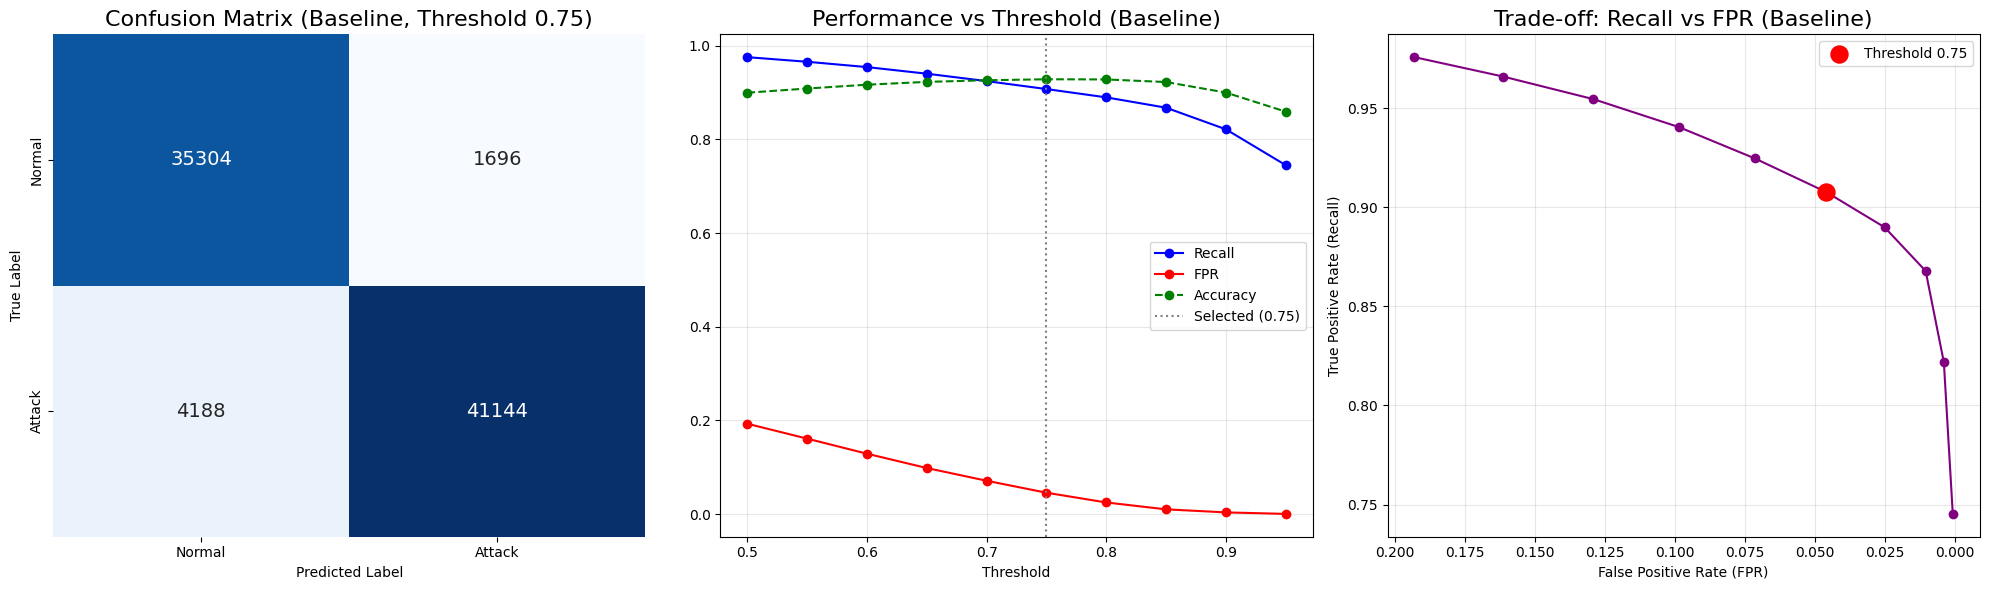


Baseline : number of selected features: 194


In [8]:
# =============================================================================
# Baseline RF: Training, Probability Prediction, and Threshold Sweep
#
# The baseline uses ALL features (no selection) to set reference metrics.
# A threshold sweep (0.50–0.95) shows how FPR/Recall trade-off changes;
# the threshold that maximises F1 is selected automatically for final plots.
# =============================================================================
print("\nBaseline Learning...")
start_time_rf = time.time()
rf_baseline.fit(x_train_scaled_full, y_train_full)
print(f"Learning Finished: {time.time() - start_time_rf:.2f}seconds")

# Retrieve attack class probabilities (column 1) for threshold tuning
y_probs_rf = rf_baseline.predict_proba(x_test_scaled)[:, 1]

# ---------------------------------------------------------
# 5. Visualisation & Trade-off Analysis (Baseline)
# ---------------------------------------------------------
print(f"\nThreshold adjustment Result (Baseline: Random Forest)")
print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10}")
print("-" * 45)

threshold_list = []
fpr_list = []
recall_list = []
accuracy_list = []

# Sweep thresholds from 0.50 to 0.95 (step 0.05)
# A star (★) marks operating points where FPR < 0.15 — IDS-safe zone
for thr in np.arange(0.5, 0.96, 0.05):
    y_pred_thr = (y_probs_rf >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    TN, FP, FN, TP = cm.ravel()
    
    fpr = FP / (FP + TN)
    rec = TP / (TP + FN)
    acc = accuracy_score(y_test, y_pred_thr)
    
    mark = "★" if fpr < 0.15 else ""
    print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {mark}")

    threshold_list.append(thr)
    fpr_list.append(fpr)
    recall_list.append(rec)
    accuracy_list.append(acc)

# Automatically select the threshold that maximises F1 score (range 0.30–0.95)
f1_scores_thr = []
for thr_tmp in np.arange(0.3, 0.96, 0.05):
    y_tmp = (y_probs_rf >= thr_tmp).astype(int)
    f1_scores_thr.append(f1_score(y_test, y_tmp, zero_division=0))
SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
print(f"\nOptimal Threshold (Max F1): {SELECTED_THRESHOLD}")
y_final_pred = (y_probs_rf >= SELECTED_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_final_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))


# 1. Confusion Matrix at optimal threshold
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Confusion Matrix (Baseline, Threshold {SELECTED_THRESHOLD})', fontsize=16)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_yticklabels(['Normal', 'Attack'])

# 2. Threshold vs. Metrics (Recall, FPR, Accuracy)
axes[1].plot(threshold_list, recall_list, marker='o', label='Recall', color='blue')
axes[1].plot(threshold_list, fpr_list, marker='o', label='FPR', color='red')
axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':', label=f'Selected ({SELECTED_THRESHOLD})')
axes[1].set_title('Performance vs Threshold (Baseline)', fontsize=16)
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Recall vs. FPR trade-off (x-axis inverted: lower FPR is better → right side)
axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5, label=f'Threshold {SELECTED_THRESHOLD}')
axes[2].set_title('Trade-off: Recall vs FPR (Baseline)', fontsize=16)
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

# Record baseline feature count for comparison in later summary plots
print(f"\nBaseline : number of selected features: {x_train_scaled_full.shape[1]}")


## 1.3. RandomForest + Optuna (hyperparameter analyis)

# 2. Genetic Algorithm

## 2.1. GA Implementation

In [10]:
# =============================================================================
# Genetic Algorithm (GA) for Feature Selection
#
# Encoding : Binary string — each bit represents inclusion (1) or exclusion (0)
#             of the corresponding feature.
# Selection : Tournament selection (size 3) — balances selection pressure and
#             diversity better than roulette wheel for binary problems.
# Crossover : 2-point crossover (prob=crossover_probability) — preserves
#             building blocks (schemata) better than single-point.
# Mutation  : Bit-flip mutation (per bit, prob=mutation_rate) — maintains
#             diversity; remediation prevents all-zero individuals.
# Elitism   : Top elite_size individuals carry over unchanged each generation.
#
# Diversity initialisation: each individual uses a random selection rate
# (10%–60%) so the initial population covers a wide range of subset sizes.
# =============================================================================
class GeneticAlgorithm:
    def __init__(self, initial_population=40, generations=40, crossover_probability=0.5, 
                 mutation_rate=0.1, elite_size=5, random_state=42):
        self.initial_population = initial_population
        self.generations = generations
        self.crossover_probability = crossover_probability
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size
        self.random_state = random_state  

        self.best_individual = None
        self.best_fitness = -np.inf
        self.fitness_history = []

    def fitness_function(self, individual, x_train, y_train, x_test, y_test):
        # Delegate to the shared fitness function defined in Cell 10
        return fitness_function(individual, x_train, y_train, x_test, y_test)

    def initialise_population(self, num_features):
        """Create initial population with varied feature selection rates (10%–60%)."""
        population = []
        for i in range(self.initial_population):
            # Vary the selection rate for each individual (distributed within the range of 10% to 60%)
            rate = self.rng.uniform(0.1, 0.6)
            individual = (self.rng.random(num_features) < rate).astype(int)
            population.append(individual)
        return np.array(population)

    def selection(self, population, fitness_scores):
        """
        Tournament selection (k=3).
        Randomly pick 3 candidates and return the fittest.
        Repeated len(population) times to produce a full mating pool.
        """
        selected = []
        for _ in range(len(population)):
            indices = self.rng.choice(len(population), 3, replace=False)
            fitness_values = fitness_scores[indices]
            best_idx = indices[np.argmax(fitness_values)]
            selected.append(population[best_idx])
        return np.array(selected)

    def crossover(self, parent1, parent2):
        """
        2-point crossover: swap the segment between two randomly chosen cut points.
        Applied with probability crossover_probability; otherwise return copies unchanged.
        """
        if self.rng.random() < self.crossover_probability:
            pts = sorted(self.rng.choice(len(parent1), 2, replace=False))
            child1 = parent1.copy()
            child2 = parent2.copy()
            child1[pts[0]:pts[1]] = parent2[pts[0]:pts[1]]
            child2[pts[0]:pts[1]] = parent1[pts[0]:pts[1]]
            return child1, child2
        return parent1.copy(), parent2.copy()
        

    def mutation(self, individual):
        """
        Bit-flip mutation: each bit is independently flipped with probability mutation_rate.
        Repair: if all bits are 0 (no features selected), randomly activate one bit.
        """
        for i in range(len(individual)):
            if self.rng.random() < self.mutation_rate:
                individual[i] = 1 - individual[i]
        
        # Remedial measures (to prevent the total from becoming zero)
        if individual.sum() == 0:
            individual[self.rng.integers(len(individual))] = 1
        return individual

    def optimise(self, x_train, y_train, x_test, y_test):
        """
        Main GA loop.
        Each generation:
          1. Evaluate fitness for all individuals.
          2. Preserve top elite_size individuals (elitism).
          3. Build next generation via tournament selection → crossover → mutation.
          4. Replace population (elites + new offspring).

        Uses an independent RNG seeded by random_state to avoid polluting
        the global numpy random state.
        """
        #  Fixed seed using an independent RNG (does not pollute the global state)
        self.rng = np.random.default_rng(self.random_state)
        self.best_fitness    = -np.inf
        self.best_individual = None
        self.fitness_history = []
        
        num_features = x_train.shape[1]
        
        print(f"GA Start: Population={self.initial_population}, Generations={self.generations}")
        print(f"Number of Features: {num_features}")

        population = self.initialise_population(num_features)
        start_time = time.time()

        for generation in range(self.generations):
            # Evaluate all individuals in parallel (vectorised loop)
            fitness_scores = np.array([
                self.fitness_function(ind, x_train, y_train, x_test, y_test)
                for ind in population
            ])

            # Track best solution found so far (global best)
            best_idx = np.argmax(fitness_scores)
            if fitness_scores[best_idx] > self.best_fitness:
                self.best_fitness = fitness_scores[best_idx]
                self.best_individual = population[best_idx].copy()

            self.fitness_history.append(self.best_fitness)

            print(f"Gen {generation+1}: Best Fitness = {self.best_fitness:.4f}, Features = {self.best_individual.sum()}")

            # --- Elitism: carry forward best individuals unchanged ---
            elite_indices = np.argsort(fitness_scores)[-self.elite_size:]
            elites = population[elite_indices].copy()

            # --- Generate offspring via selection → crossover → mutation ---
            selected = self.selection(population, fitness_scores)
            next_generation = []
            
            for i in range(0, len(selected) - 1, 2):
                c1, c2 = self.crossover(selected[i], selected[i+1])
                c1 = self.mutation(c1)
                c2 = self.mutation(c2)
                next_generation.extend([c1, c2])

            # Combine elites and new offspring; trim/pad to exact population size
            num_to_fill = self.initial_population - self.elite_size
            population = np.vstack([elites, next_generation[:num_to_fill]])

        total_time = time.time() - start_time
        print(f"GA Complete: {total_time:.2f}s, Best Fitness: {self.best_fitness:.4f}")
        
        return self.best_individual


## 2.2. GA - Execution

GA開始: Population=50, Generations=50
特徴量数: 194
Gen 1: Best Fitness = 0.9603, Features = 94
Gen 2: Best Fitness = 0.9604, Features = 98
Gen 3: Best Fitness = 0.9604, Features = 98
Gen 4: Best Fitness = 0.9608, Features = 116
Gen 5: Best Fitness = 0.9610, Features = 99
Gen 6: Best Fitness = 0.9616, Features = 113
Gen 7: Best Fitness = 0.9616, Features = 113
Gen 8: Best Fitness = 0.9616, Features = 113
Gen 9: Best Fitness = 0.9617, Features = 115
Gen 10: Best Fitness = 0.9618, Features = 119
Gen 11: Best Fitness = 0.9618, Features = 111
Gen 12: Best Fitness = 0.9619, Features = 114
Gen 13: Best Fitness = 0.9620, Features = 113
Gen 14: Best Fitness = 0.9620, Features = 113
Gen 15: Best Fitness = 0.9620, Features = 113
Gen 16: Best Fitness = 0.9620, Features = 113
Gen 17: Best Fitness = 0.9622, Features = 112
Gen 18: Best Fitness = 0.9622, Features = 112
Gen 19: Best Fitness = 0.9622, Features = 112
Gen 20: Best Fitness = 0.9626, Features = 106
Gen 21: Best Fitness = 0.9626, Features = 106
G

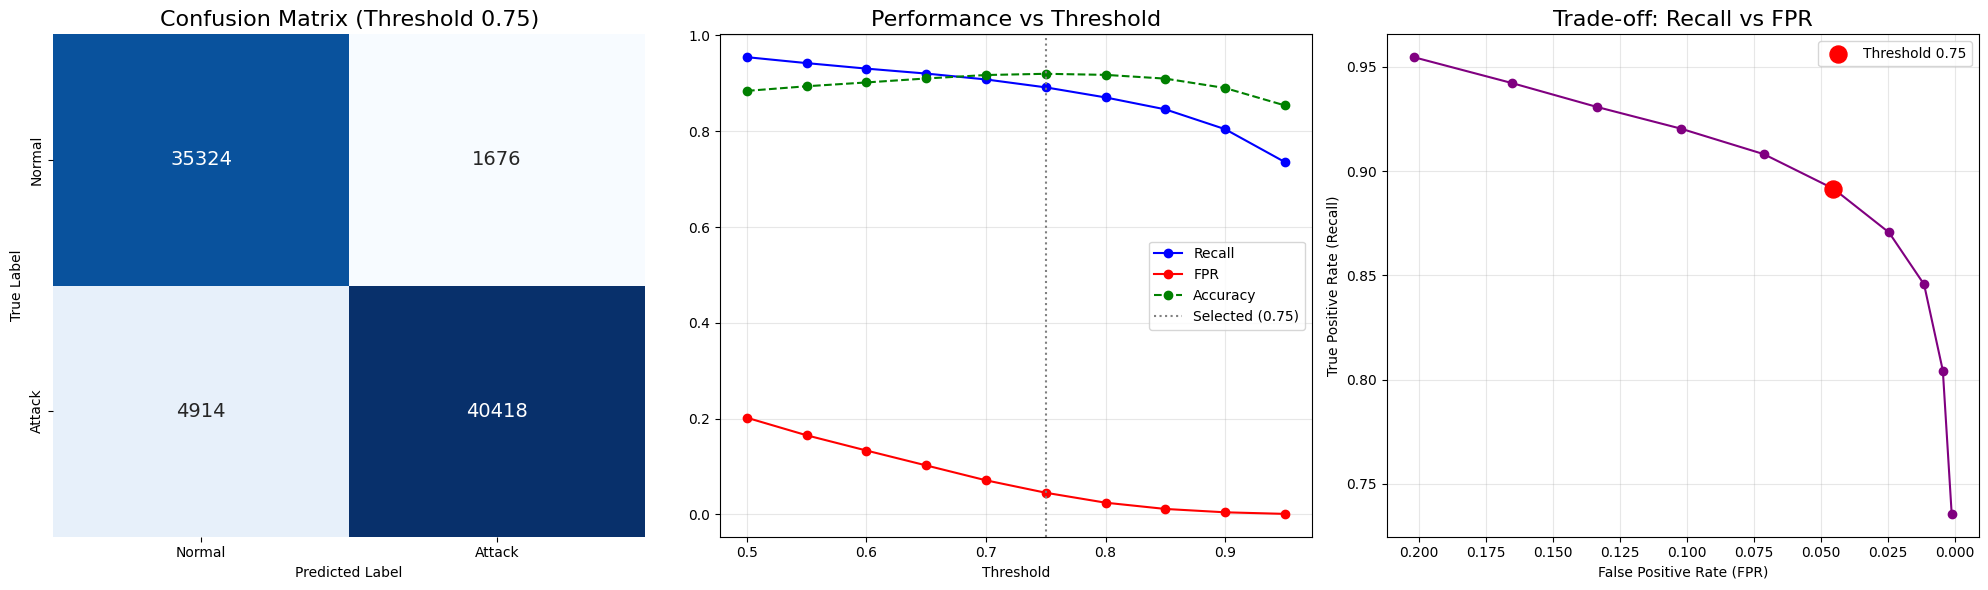

In [ ]:
# =============================================================================
# GA: Feature Selection Execution
#
# Phase 1 (Feature Selection): GA searches for the best binary feature mask
#   using the small optimisation subset (x_train_opt / x_val_opt) for speed.
#
# Phase 2 (Final Model): The selected features are applied to the full training
#   set, and an RF is trained with fixed hyperparameters for fair comparison
#   across all metaheuristics before Optuna tuning.
#
# Hyperparameters:
#   population=50, generations=50 : large enough for 40+ features
#   crossover_prob=0.7            : high crossover encourages exploration
#   mutation_rate=0.03            : low per-bit mutation preserves good solutions
#   elite_size=3                  : small elite to avoid premature convergence
# =============================================================================

# Instantiation
ga = GeneticAlgorithm(
    initial_population=50,
    generations=50,
    crossover_probability=0.7,
    mutation_rate=0.03,
    elite_size=3,
    random_state=42
)

# Phase 1: Feature selection using the small search subset
start_time_ga = time.time()
best_mask_ga = ga.optimise(x_train_opt, y_train_opt, x_val_opt, y_val_opt)
print(f"Genetic Algorithm execution finished in: {time.time() - start_time_ga}")

# Convert binary mask to boolean index array
selected_features_ga = best_mask_ga == 1
print(f"Final Selected number of Features: {selected_features_ga.sum()}")


# ---------------------------------------------------------
# Phase 2: Final Model Training & Threshold Adjustment
# ---------------------------------------------------------

# Apply selected feature mask to full training and test sets
x_train_final = x_train_scaled_full[:, selected_features_ga]
x_test_final = x_test_scaled[:, selected_features_ga]

# Fixed RF (same config as baseline) for apples-to-apples comparison before Optuna
final_rf_ga = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining the final model...")
start_time = time.time()
final_rf_ga.fit(x_train_final, y_train_full)
print(f"time: {time.time() - start_time}s")

# Get predicted probabilities for threshold sweep
y_probs_ga = final_rf_ga.predict_proba(x_test_final)[:, 1]


# ---------------------------------------------------------
# Visualization & Trade-off Analysis (GA, fixed RF)
# ---------------------------------------------------------
print(f"\n[Threshold Adjustment Results (GA)]")
print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10}")
print("-" * 45)

threshold_list = []
fpr_list = []
recall_list = []
accuracy_list = []


for thr in np.arange(0.5, 0.96, 0.05):
    y_pred_thr = (y_probs_ga >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    TN, FP, FN, TP = cm.ravel()
    
    fpr = FP / (FP + TN)
    rec = TP / (TP + FN)
    acc = accuracy_score(y_test, y_pred_thr)
    
    mark = "★" if fpr < 0.15 else ""
    print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {mark}")
    
    threshold_list.append(thr)
    fpr_list.append(fpr)
    recall_list.append(rec)
    accuracy_list.append(acc)

# Automatically select the threshold that maximizes the F1 score (use the optimal threshold instead of a fixed value of 0.75)
f1_scores_thr = []
for thr_tmp in np.arange(0.3, 0.96, 0.05):
    y_tmp = (y_probs_ga >= thr_tmp).astype(int)
    f1_scores_thr.append(f1_score(y_test, y_tmp, zero_division=0))
SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
print(f"Optimal Threshold (Max F1): {SELECTED_THRESHOLD}")
y_final_pred = (y_probs_ga >= SELECTED_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_final_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Confusion Matrix (Threshold {SELECTED_THRESHOLD})', fontsize=16)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_yticklabels(['Normal', 'Attack'])

# 2. Threshold Performance
axes[1].plot(threshold_list, recall_list, marker='o', label='Recall', color='blue')
axes[1].plot(threshold_list, fpr_list, marker='o', label='FPR', color='red')
axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':', label=f'Selected ({SELECTED_THRESHOLD})')
axes[1].set_title('Performance vs Threshold', fontsize=16)
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Trade-off (Recall vs FPR)
axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5, label=f'Threshold {SELECTED_THRESHOLD}')
axes[2].set_title('Trade-off: Recall vs FPR', fontsize=16)
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()


## 2.3. GA + Optuna

--- GA + Optuna: Hyperparameter Tuning Start ---


[I 2026-03-14 16:45:14,276] A new study created in memory with name: no-name-b5bb8968-fe23-4684-8655-c3126c88b1f2
[I 2026-03-14 16:45:19,586] Trial 0 finished with value: 0.894334698085173 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.894334698085173.
[I 2026-03-14 16:45:21,568] Trial 1 finished with value: 0.8918067734172916 and parameters: {'n_estimators': 64, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.894334698085173.
[I 2026-03-14 16:45:29,553] Trial 2 finished with value: 0.8926510690430682 and parameters: {'n_estimators': 258, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.894334698085173.
[I 2026-03-14 16:45:34,624] Trial 3 finished with value: 0.8935680078767203 and parameters: {'n_estimators': 158, 'max_depth': 21, 'min_


Best Params: {'n_estimators': 239, 'max_depth': 27, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Best F1 Score (Validation): 0.8950

【GA + Optuna 最終評価結果】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.2088     0.9567     0.8823     0.8995     
0.55       0.1724     0.9445     0.8919     0.9059     
0.60       0.1427     0.9342     0.8997     0.9111     ★
0.65       0.1099     0.9233     0.9083     0.9173     ★
0.70       0.0806     0.9115     0.9150     0.9220     ★
0.75       0.0507     0.8959     0.9199     0.9249     ★
0.80       0.0295     0.8752     0.9180     0.9216     ★
0.85       0.0135     0.8455     0.9089     0.9108     ★
0.90       0.0055     0.8063     0.8909     0.8905     ★
0.95       0.0014     0.7454     0.8592     0.8536     ★
最適閾値 (F1最大): 0.75


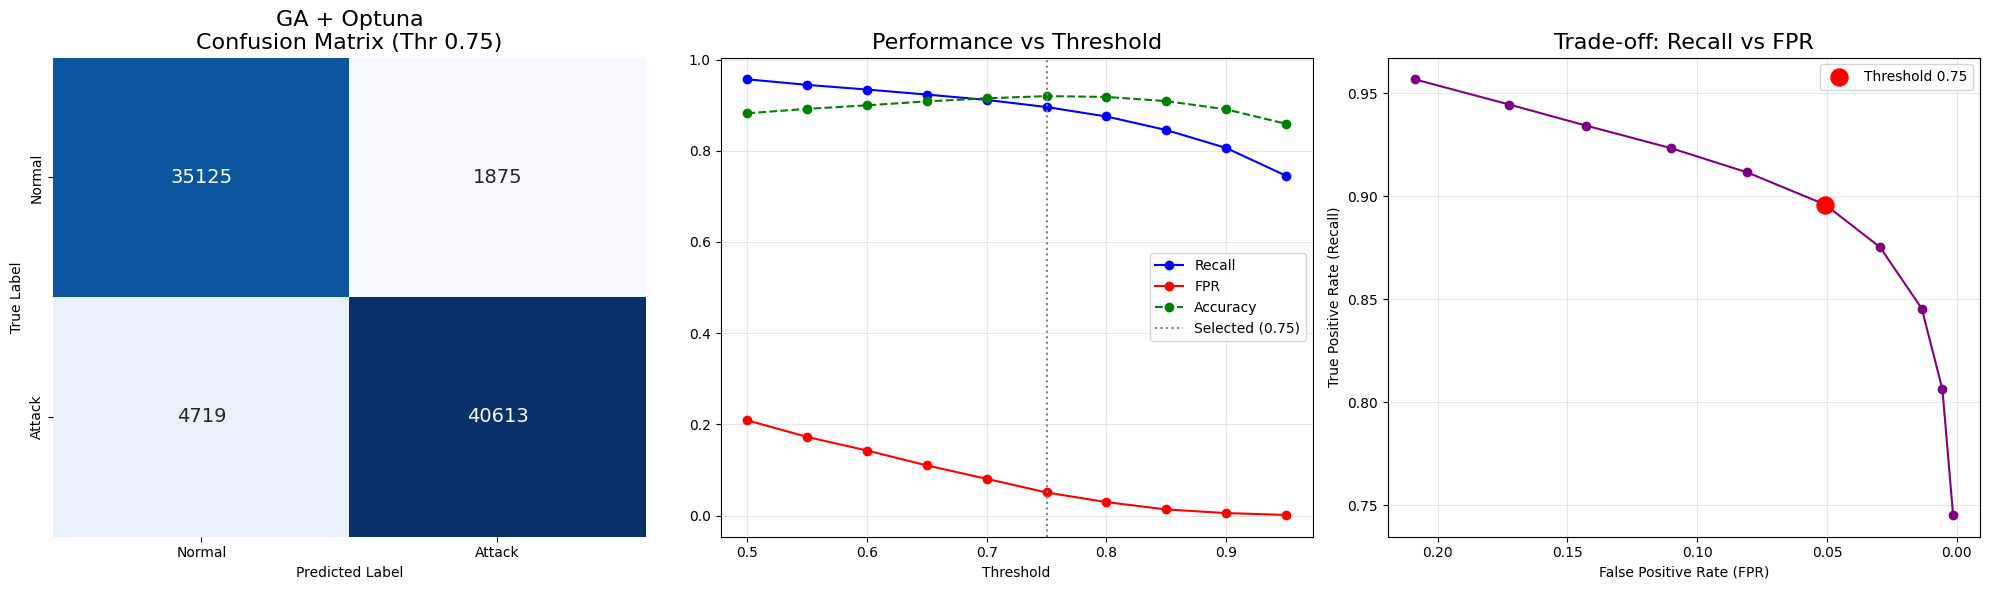

In [12]:
# =============================================================================
# GA + Optuna: Hyperparameter Tuning on GA-Selected Features
# Purpose: Assess additional gains from tuning RF hyperparameters on the
#          feature subset already identified by GA.
# =============================================================================
ALGORITHM_NAME = "GA + Optuna"
TARGET_MASK    = selected_features_ga  # Boolean mask from GA feature selection

best_model_opt, x_test_opt = run_optuna_optimization(
    TARGET_MASK, 
    x_train_opt, y_train_opt,           # Same data as for feature selection
    x_train_scaled_full, y_train_full,  # Data for final training
    x_test_scaled, y_test,
    ALGORITHM_NAME
)

y_probs_opt = best_model_opt.predict_proba(x_test_opt)[:, 1]
evaluate_and_plot(y_probs_opt, y_test, ALGORITHM_NAME)


# 3. Ant Colony Optimisation

## 3.1. ACO Implementation

In [13]:
# =============================================================================
# Ant Colony Optimisation (ACO) for Feature Selection
#
# Concept:
#   Inspired by ant foraging behaviour: ants deposit pheromones on useful
#   paths; paths with more pheromone are more likely to be chosen by future ants.
#
# Representation:
#   Each feature has a pheromone level τ_i and a heuristic η_i.
#   Heuristic = RF feature importances (pre-computed once before the main loop).
#   A feature is included if a random draw < sigmoid(normalised desirability).
#
# Key design decisions:
#   - Sigmoid mapping (not direct normalisation) prevents probabilities from
#     collapsing to 0 or 1 early in the search.
#   - Adaptive exploration rate: high at start (diverse solutions), low at end
#     (exploitation of high-pheromone features).
#   - Only ants with positive fitness contribute pheromone deposits (Q * fit).
#   - Pheromone evaporation (1 - evaporation_rate) prevents stagnation.
# =============================================================================
class AntColonyOptimisation:
    def __init__(self, num_ants=30, iterations=50, alpha=1.0, beta=1.0, 
                 evaporation_rate=0.1, Q=1.0, random_state=42):
        self.num_ants = num_ants          # Number of ants per iteration
        self.iterations = iterations      # Number of optimisation iterations
        self.alpha = alpha                # Pheromone influence exponent (τ^α)
        self.beta = beta                  # Heuristic influence exponent (η^β)
        self.evaporation_rate = evaporation_rate  # Pheromone decay per iteration
        self.Q = Q                        # Pheromone deposit scaling constant
        self.random_state = random_state

        self.best_solution = None
        self.best_fitness = -np.inf
        self.fitness_history = []
        
        # Internal RNG (independent of global numpy state)
        self.rng = np.random.default_rng(random_state)

    def fitness_function(self, individual, x_train, y_train, x_test, y_test):
        return fitness_function(individual, x_train, y_train, x_test, y_test)
        
    def initialise_pheromone(self, n_features):
        """Uniform pheromone initialisation: all features equally attractive at start."""
        return np.ones(n_features)

    def calculate_heuristics(self, x_train, y_train):
        """
        Compute feature importance heuristic using a lightweight RF.
        Adding 1e-10 ensures no feature has zero desirability (prevents division issues).
        This is computed ONCE before the main loop to save runtime.
        """
        rf = RandomForestClassifier(
            n_estimators=100, max_depth=20, 
            random_state=42, n_jobs=-1, class_weight='balanced'
        )
        rf.fit(x_train, y_train)
        return rf.feature_importances_ + 1e-10

    def construct_solution(self, pheromone, heuristic, n_features):
        """
        Build one ant's solution (binary feature mask).

        Desirability = τ^α * η^β  (pheromone × heuristic)
        Sigmoid normalisation converts to probabilities in (0,1).
        Adaptive exploration blends probabilities toward 0.5 early in the search
        (exploration) and uses pheromone-driven probabilities later (exploitation).
        """
        desirability = (pheromone ** self.alpha) * (heuristic ** self.beta)
    
        # Z-score normalise, then apply sigmoid → probabilities in (0,1)
        d_norm = (desirability - desirability.mean()) / (desirability.std() + 1e-10)
        probs = 1 / (1 + np.exp(-d_norm))  # Sigmoid
        
        # Adaptive exploration: blend toward uniform 0.5 in early iterations
        # exploration_rate decays from ~0.5 (start) to 0.05 (end)
        exploration_rate = max(0.05, 0.5 * (1.0 - self.iteration_ratio))
        final_probs = (1 - exploration_rate) * probs + exploration_rate * 0.5
        
        solution = (self.rng.random(n_features) < final_probs).astype(int)
        if solution.sum() == 0:  # Feasibility repair
            solution[self.rng.integers(n_features)] = 1
        return solution
        

    def update_pheromone(self, pheromone, solutions, fitness_scores):
        """
        Pheromone update rule:
          1. Evaporate all pheromones: τ_i ← τ_i * (1 - ρ)
          2. Deposit Q*fitness on features selected by ants with positive fitness.
        Only positive-fitness solutions contribute (prevents reward for infeasible masks).
        """
        pheromone *= (1 - self.evaporation_rate)
        
        for sol, fit in zip(solutions, fitness_scores):
            if fit > 0:
                pheromone[sol == 1] += self.Q * fit
        
        return pheromone

    def optimise(self, x_train, y_train, x_test, y_test):
        """Main ACO loop: iterate, construct solutions, evaluate, update pheromones."""
        # Reset all state for reproducibility
        self.rng = np.random.default_rng(self.random_state)   
        self.best_fitness    = -np.inf
        self.best_solution   = None
        self.fitness_history = []
        
        n_features = x_train.shape[1]
        
        print(f"ACO Start: Ants={self.num_ants}, Iterations={self.iterations}")
        print(f"Number of Features: {n_features}")

        # Initialise pheromone and heuristic vectors
        pheromone = self.initialise_pheromone(n_features)
        heuristic = self.calculate_heuristics(x_train, y_train)
        
        start_time = time.time()

        for iteration in range(self.iterations):
            self.iteration_ratio = iteration / self.iterations  # Used in construct_solution
            solutions = []
            fitness_scores = []
            
            # Each ant constructs and evaluates a solution
            for _ in range(self.num_ants):
                sol = self.construct_solution(pheromone, heuristic, n_features)
                fit = self.fitness_function(sol, x_train, y_train, x_test, y_test)
                
                solutions.append(sol)
                fitness_scores.append(fit)
                
                # Update global best immediately (online update)
                if fit > self.best_fitness:
                    self.best_fitness = fit
                    self.best_solution = sol.copy()
            
            # Update pheromone trails based on all ants' solutions
            pheromone = self.update_pheromone(pheromone, solutions, fitness_scores)
            
            self.fitness_history.append(self.best_fitness)
            
            print(f"Iter {iteration+1}: Best Fitness = {self.best_fitness:.4f}, Features = {self.best_solution.sum()}")

        total_time = time.time() - start_time
        print(f"ACO Complete: {total_time:.2f}s, Best Fitness: {self.best_fitness:.4f}")
        
        return self.best_solution


--- Baseline RF + Optuna: Hyperparameter Tuning Start ---


[I 2026-03-14 13:29:04,954] A new study created in memory with name: no-name-f7dfa257-e2d1-4b78-96dc-be517e79e058
[I 2026-03-14 13:29:23,545] Trial 0 finished with value: 0.9455369177896897 and parameters: {'n_estimators': 175, 'max_depth': 49, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9455369177896897.
[I 2026-03-14 13:29:31,872] Trial 1 finished with value: 0.9431775612465495 and parameters: {'n_estimators': 111, 'max_depth': 46, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.9455369177896897.
[I 2026-03-14 13:29:53,148] Trial 2 finished with value: 0.944834065602578 and parameters: {'n_estimators': 267, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.9455369177896897.
[I 2026-03-14 13:30:08,201] Trial 3 finished with value: 0.9453620939341197 and parameters: {'n_estimators': 186, 'max_depth': 25, '


Best Params: {'n_estimators': 269, 'max_depth': 28, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Best F1 Score (Validation): 0.9460

【Baseline RF + Optuna 最終評価結果】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.1913     0.9743     0.8998     0.9146     
0.55       0.1607     0.9651     0.9086     0.9208     
0.60       0.1286     0.9544     0.9171     0.9269     ★
0.65       0.1009     0.9413     0.9223     0.9303     ★
0.70       0.0730     0.9255     0.9262     0.9325     ★
0.75       0.0478     0.9084     0.9281     0.9329     ★
0.80       0.0264     0.8918     0.9286     0.9322     ★
0.85       0.0111     0.8679     0.9223     0.9248     ★
0.90       0.0040     0.8228     0.9006     0.9011     ★
0.95       0.0011     0.7528     0.8634     0.8585     ★
最適閾値 (F1最大): 0.75


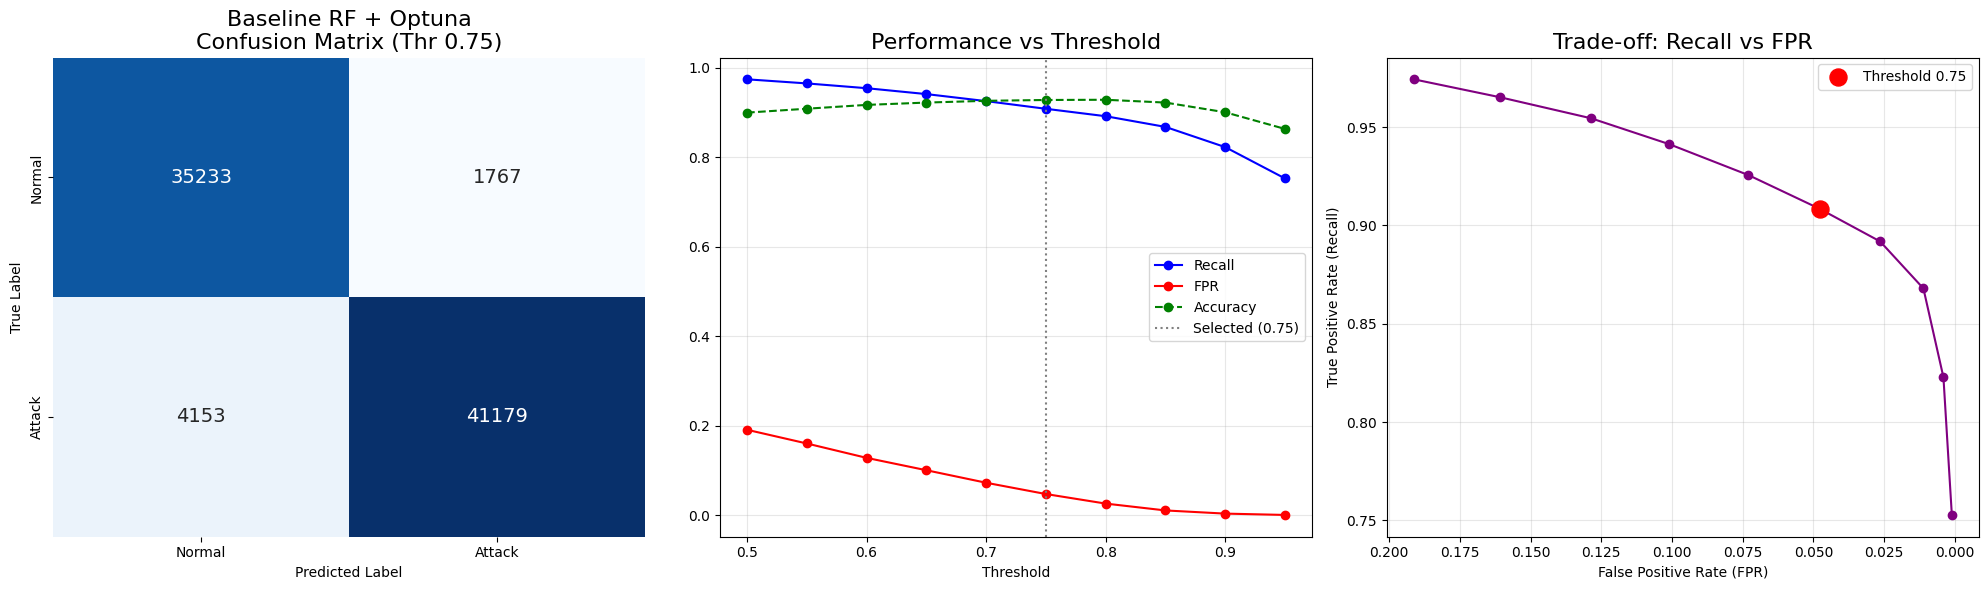

In [9]:
# =============================================================================
# Baseline RF + Optuna Hyperparameter Tuning
# Purpose: Compare the effect of Optuna tuning on the baseline (all features).
#          This separates the contribution of feature selection from hyperparameter
#          tuning when interpreting metaheuristic results.
# =============================================================================
ALGORITHM_NAME = "Baseline RF + Optuna"

best_model_opt = run_optuna_optimization_rf(
    x_train_scaled_full, y_train_full, x_test_scaled, y_test, ALGORITHM_NAME
)

y_probs_opt = best_model_opt.predict_proba(x_test_scaled)[:, 1]
evaluate_and_plot(y_probs_opt, y_test, ALGORITHM_NAME)


## 3.2. ACO execution

ACO開始: Ants=20, Iterations=30
特徴量数: 194
Iter 1: Best Fitness = 0.9599, Features = 98
Iter 2: Best Fitness = 0.9600, Features = 92
Iter 3: Best Fitness = 0.9600, Features = 92
Iter 4: Best Fitness = 0.9602, Features = 100
Iter 5: Best Fitness = 0.9602, Features = 100
Iter 6: Best Fitness = 0.9603, Features = 101
Iter 7: Best Fitness = 0.9603, Features = 101
Iter 8: Best Fitness = 0.9607, Features = 95
Iter 9: Best Fitness = 0.9609, Features = 96
Iter 10: Best Fitness = 0.9609, Features = 96
Iter 11: Best Fitness = 0.9609, Features = 96
Iter 12: Best Fitness = 0.9609, Features = 96
Iter 13: Best Fitness = 0.9609, Features = 96
Iter 14: Best Fitness = 0.9609, Features = 96
Iter 15: Best Fitness = 0.9609, Features = 96
Iter 16: Best Fitness = 0.9609, Features = 96
Iter 17: Best Fitness = 0.9609, Features = 96
Iter 18: Best Fitness = 0.9609, Features = 96
Iter 19: Best Fitness = 0.9609, Features = 96
Iter 20: Best Fitness = 0.9609, Features = 96
Iter 21: Best Fitness = 0.9609, Features = 96

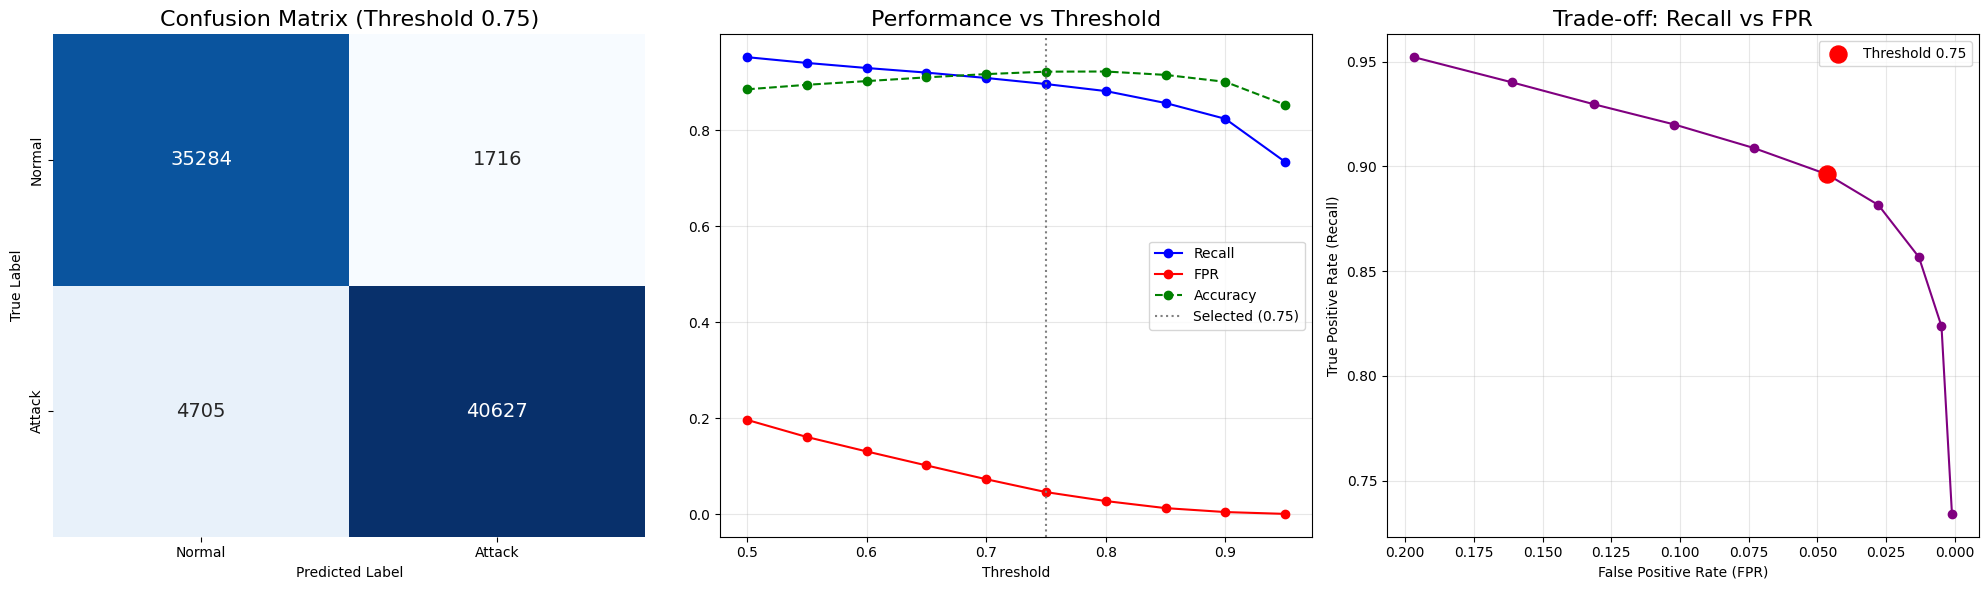

In [ ]:
# ---------------------------------------------------------
# 3. Execution Part
# ---------------------------------------------------------

# Instantiation 
aco = AntColonyOptimisation(
    num_ants=20,
    iterations=30, 
    alpha=1.0,
    beta=1.5,       # Heuristic-oriented
    evaporation_rate=0.3,
    random_state=42
)

# Run Optimization (Using the search dataset)
start_time_aco = time.time()
best_mask_aco = aco.optimise(x_train_opt, y_train_opt, x_val_opt, y_val_opt)
print(f"Ant Colony Optimisation execution finished in: {time.time() - start_time_aco}")

# Mask Transformation
selected_features_aco = best_mask_aco == 1
print(f"Final Selected number of Features: {selected_features_aco.sum()}")

# ---------------------------------------------------------
# 4. Final Model Training & Threshold Adjustment (Standard)
# ---------------------------------------------------------

# Train the final model using the entire dataset
x_train_final = x_train_scaled_full[:, selected_features_aco]
x_test_final = x_test_scaled[:, selected_features_aco]

final_rf_aco = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining the final model...")
start_time = time.time()
final_rf_aco.fit(x_train_final, y_train_full)
print(f"time: {time.time() - start_time}s")

# Retrieving the prediction probability
y_probs_aco = final_rf_aco.predict_proba(x_test_final)[:, 1]

# ---------------------------------------------------------
# 5. Visualization & Trade-off Analysis
# ---------------------------------------------------------
print(f"\n[Threshold Adjustment Results (ACO)]")
print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10} {'F1':<10}")
print("-" * 55)

threshold_list = []
fpr_list = []
recall_list = []
accuracy_list = []

# 0.5 -> 0.95
for thr in np.arange(0.5, 0.96, 0.05):
    y_pred_thr = (y_probs_aco >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    TN, FP, FN, TP = cm.ravel()
    
    fpr = FP / (FP + TN)
    rec = TP / (TP + FN)
    acc = accuracy_score(y_test, y_pred_thr)
    
    f1 = f1_score(y_test, y_pred_thr, zero_division=0)
    mark = "★" if fpr < 0.15 else ""
    print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {f1:<10.4f} {mark}")
    
    threshold_list.append(thr)
    fpr_list.append(fpr)
    recall_list.append(rec)
    accuracy_list.append(acc)

# Plotting Graphs
# Automatically select the threshold that maximizes the F1 score (use the optimal threshold instead of a fixed value of 0.75)
f1_scores_thr = []
for thr_tmp in np.arange(0.3, 0.96, 0.05):
    y_tmp = (y_probs_aco >= thr_tmp).astype(int)
    f1_scores_thr.append(f1_score(y_test, y_tmp, zero_division=0))
SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
print(f"Optimal Threshold (Max F1): {SELECTED_THRESHOLD}")
y_final_pred = (y_probs_aco >= SELECTED_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_final_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Confusion Matrix (Threshold {SELECTED_THRESHOLD})', fontsize=16)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_yticklabels(['Normal', 'Attack'])

# 2. Threshold Performance
axes[1].plot(threshold_list, recall_list, marker='o', label='Recall', color='blue')
axes[1].plot(threshold_list, fpr_list, marker='o', label='FPR', color='red')
axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':', label=f'Selected ({SELECTED_THRESHOLD})')
axes[1].set_title('Performance vs Threshold', fontsize=16)
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Trade-off (Recall vs FPR)
axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
# Highlighting Selected Points
idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5, label=f'Threshold {SELECTED_THRESHOLD}')
axes[2].set_title('Trade-off: Recall vs FPR', fontsize=16)
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].invert_xaxis() # Since a lower FPR is better, move to the right (lower)

plt.tight_layout()
plt.show()

## 3.3. ACO + Optuna

--- ACO + Optuna: Hyperparameter Tuning Start ---


[I 2026-03-14 17:36:50,929] A new study created in memory with name: no-name-ee1d3e06-f173-4b7c-97ef-31730596f8e9
[I 2026-03-14 17:36:57,320] Trial 0 finished with value: 0.8949111951533257 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8949111951533257.
[I 2026-03-14 17:36:59,693] Trial 1 finished with value: 0.8921137280898803 and parameters: {'n_estimators': 64, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.8949111951533257.
[I 2026-03-14 17:37:08,752] Trial 2 finished with value: 0.8934273257455972 and parameters: {'n_estimators': 258, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.8949111951533257.
[I 2026-03-14 17:37:14,666] Trial 3 finished with value: 0.8935134005797474 and parameters: {'n_estimators': 158, 'max_depth': 21, '


Best Params: {'n_estimators': 299, 'max_depth': 28, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
Best F1 Score (Validation): 0.8952

【ACO + Optuna 最終評価結果】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.1908     0.9512     0.8874     0.9030     
0.55       0.1571     0.9397     0.8962     0.9088     
0.60       0.1284     0.9287     0.9031     0.9134     ★
0.65       0.1004     0.9191     0.9104     0.9187     ★
0.70       0.0708     0.9087     0.9179     0.9242     ★
0.75       0.0454     0.8958     0.9222     0.9269     ★
0.80       0.0263     0.8801     0.9222     0.9256     ★
0.85       0.0119     0.8565     0.9157     0.9179     ★
0.90       0.0047     0.8219     0.8999     0.9004     ★
0.95       0.0011     0.7268     0.8491     0.8414     ★
最適閾値 (F1最大): 0.75


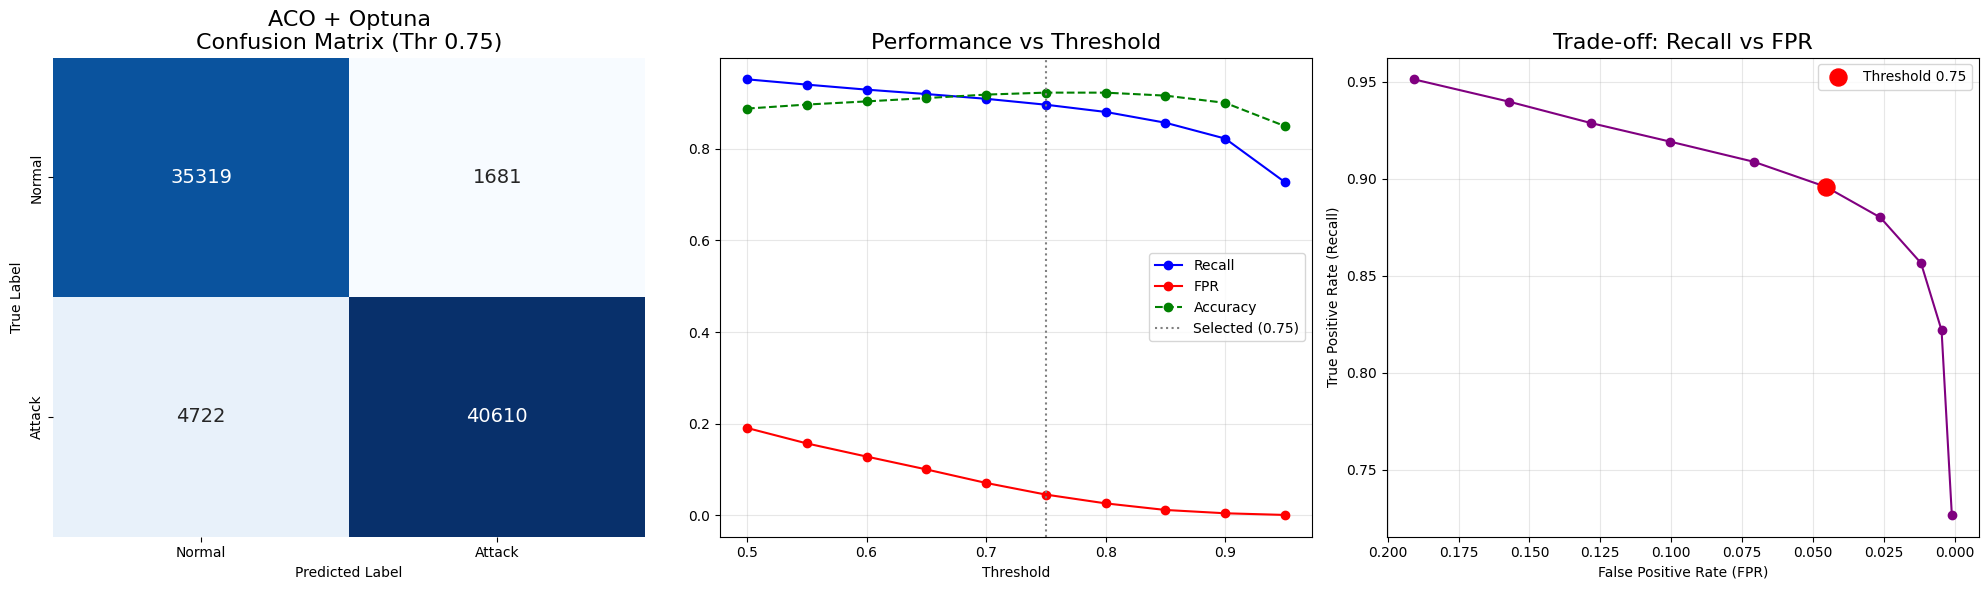

In [15]:
ALGORITHM_NAME = "ACO + Optuna"
TARGET_MASK    = selected_features_aco

best_model_opt, x_test_opt = run_optuna_optimization(
    TARGET_MASK,
    x_train_opt, y_train_opt,           # Same data as for feature selection
    x_train_scaled_full, y_train_full,  # Data for final training
    x_test_scaled, y_test,
    ALGORITHM_NAME
)

y_probs_opt = best_model_opt.predict_proba(x_test_opt)[:, 1]
evaluate_and_plot(y_probs_opt, y_test, ALGORITHM_NAME)

# 4. Grey Wolf Optimiser

## 4.1. GWO Implementation

In [16]:
# =============================================================================
# Grey Wolf Optimiser (GWO) for Feature Selection
#
# Concept:
#   Inspired by the leadership hierarchy and hunting behaviour of grey wolves:
#     α (alpha) : best solution found so far
#     β (beta)  : second-best
#     δ (delta) : third-best
#     ω (omega) : rest of the pack
#
# Each wolf updates its position toward α, β, and δ simultaneously.
# The coefficient a decreases linearly from 2→0, shifting the search from
# exploration (large |A|) to exploitation (small |A|) over iterations.
#
# Binary conversion:
#   Wolves maintain continuous positions in [0,1].
#   A steep sigmoid (k=10, centred at 0.5) maps positions to probabilities.
#   Each dimension is stochastically binarised: bit_i = 1 if rand < sigmoid(pos_i).
#
# Design notes:
#   - The best_solution is stored as the binary vector, not the continuous position,
#     because the fitness is defined on the binary feature mask.
#   - All three leaders contribute equally (averaged) to position updates.
# =============================================================================
class GreyWolfOptimisation:
    def __init__(self, n_wolves=10, max_iter=20, random_state=42):
        self.n_wolves = n_wolves    # Pack size
        self.max_iter = max_iter    # Number of hunting iterations
        self.random_state = random_state
        
        self.best_solution = None
        self.best_fitness = -np.inf
        self.fitness_history = []

    def _sigmoid(self, x):
        """Steep sigmoid centred at 0.5 for binary transfer; maps continuous positions to probabilities."""
        return 1 / (1 + np.exp(-10 * (x - 0.5)))

    def fitness_function(self, individual, x_train, y_train, x_test, y_test):
        return fitness_function(individual, x_train, y_train, x_test, y_test)
        
    def optimise(self, x_train, y_train, x_test, y_test):
        """
        Main GWO loop.
        Steps each iteration:
          1. Binarise each wolf's continuous position via sigmoid + stochastic threshold.
          2. Evaluate fitness for each binary vector.
          3. Update α, β, δ hierarchy.
          4. Update all wolf positions using average of α, β, δ guidance vectors.
        """
        self.rng = np.random.default_rng(self.random_state)
        self.best_fitness    = -np.inf
        self.best_solution   = None
        self.fitness_history = []
    
        n_features = x_train.shape[1]
        
        print(f"GWO Start: Wolves={self.n_wolves}, Iterations={self.max_iter}")
        print(f"Number of Features: {n_features}")
        
        start_time = time.time()

        # Initialise wolves with random continuous positions in [0,1]
        wolves_position = self.rng.random((self.n_wolves, n_features))
        
        # Initialise leader positions (continuous) and scores
        alpha_pos = np.zeros(n_features)
        alpha_score = -float("inf")
        
        beta_pos = np.zeros(n_features)
        beta_score = -float("inf")
        
        delta_pos = np.zeros(n_features)
        delta_score = -float("inf")

        for iteration in range(self.max_iter):
            # --- Step 1 & 2: Evaluate each wolf ---
            for i in range(self.n_wolves):
                # Convert continuous position to binary feature mask
                probs = self._sigmoid(wolves_position[i])
                binary_vector = (self.rng.random(n_features) < probs).astype(int)
                
                fitness = self.fitness_function(binary_vector, x_train, y_train, x_test, y_test)
                
                # --- Step 3: Update leader hierarchy (α > β > δ) ---
                if fitness > alpha_score:
                    # Cascade: old α → β, old β → δ, new α
                    delta_score = beta_score
                    delta_pos = beta_pos.copy()
                    beta_score = alpha_score
                    beta_pos = alpha_pos.copy()
                    alpha_score = fitness
                    alpha_pos = wolves_position[i].copy()
                    
                    # Record the best binary solution seen
                    self.best_solution = binary_vector.copy()
                    self.best_fitness = fitness
                    
                elif fitness > beta_score:
                    delta_score = beta_score
                    delta_pos = beta_pos.copy()
                    beta_score = fitness
                    beta_pos = wolves_position[i].copy()
                    
                elif fitness > delta_score:
                    delta_score = fitness
                    delta_pos = wolves_position[i].copy()
            
            # Save convergence history
            self.fitness_history.append(alpha_score)
            
            # a decays from 2 → 0: controls exploration/exploitation balance
            a = 2 - iteration * (2 / self.max_iter)
            
            # --- Step 4: Update each wolf's position ---
            for i in range(self.n_wolves):
                for j in range(n_features):
                    # Contribution from alpha
                    r1, r2 = self.rng.random(), self.rng.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * alpha_pos[j] - wolves_position[i, j])
                    X1 = alpha_pos[j] - A1 * D_alpha
                    
                    # Contribution from beta
                    r1, r2 = self.rng.random(), self.rng.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * beta_pos[j] - wolves_position[i, j])
                    X2 = beta_pos[j] - A2 * D_beta
                    
                    # Contribution from delta
                    r1, r2 = self.rng.random(), self.rng.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * delta_pos[j] - wolves_position[i, j])
                    X3 = delta_pos[j] - A3 * D_delta
                    
                    # Average the three leader guidance vectors
                    wolves_position[i, j] = (X1 + X2 + X3) / 3
            
            if (iteration + 1) % 5 == 0:
                print(f"Iter {iteration+1}: Best Fitness = {alpha_score:.4f}, Features = {self.best_solution.sum()}")

        total_time = time.time() - start_time
        print(f"GWO Complete: {total_time:.2f}s, Best Fitness: {self.best_fitness:.4f}")
        
        return self.best_solution


## 4.2. GWO execution

GWO開始: Wolves=15, Iterations=50
特徴量数: 194
Iter 5: Best Fitness = 0.9606, Features = 82
Iter 10: Best Fitness = 0.9613, Features = 82
Iter 15: Best Fitness = 0.9616, Features = 72
Iter 20: Best Fitness = 0.9616, Features = 72
Iter 25: Best Fitness = 0.9616, Features = 68
Iter 30: Best Fitness = 0.9618, Features = 76
Iter 35: Best Fitness = 0.9619, Features = 72
Iter 40: Best Fitness = 0.9620, Features = 66
Iter 45: Best Fitness = 0.9620, Features = 66
Iter 50: Best Fitness = 0.9620, Features = 66
GWO完了: 3056.90秒, Best Fitness: 0.9620
Grey Wolf Optimisation execution finished in: 3056.8995702266693
最終選択特徴量数: 66

最終モデル学習中...
time: 13.845651388168335s

【閾値調整結果 (GWO)】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.2024     0.9554     0.8845     0.9011     
0.55       0.1667     0.9412     0.8927     0.9062     
0.60       0.1294     0.9277     0.9021     0.9125     ★
0.65       0.0974     0.9147     0.9092     0.91

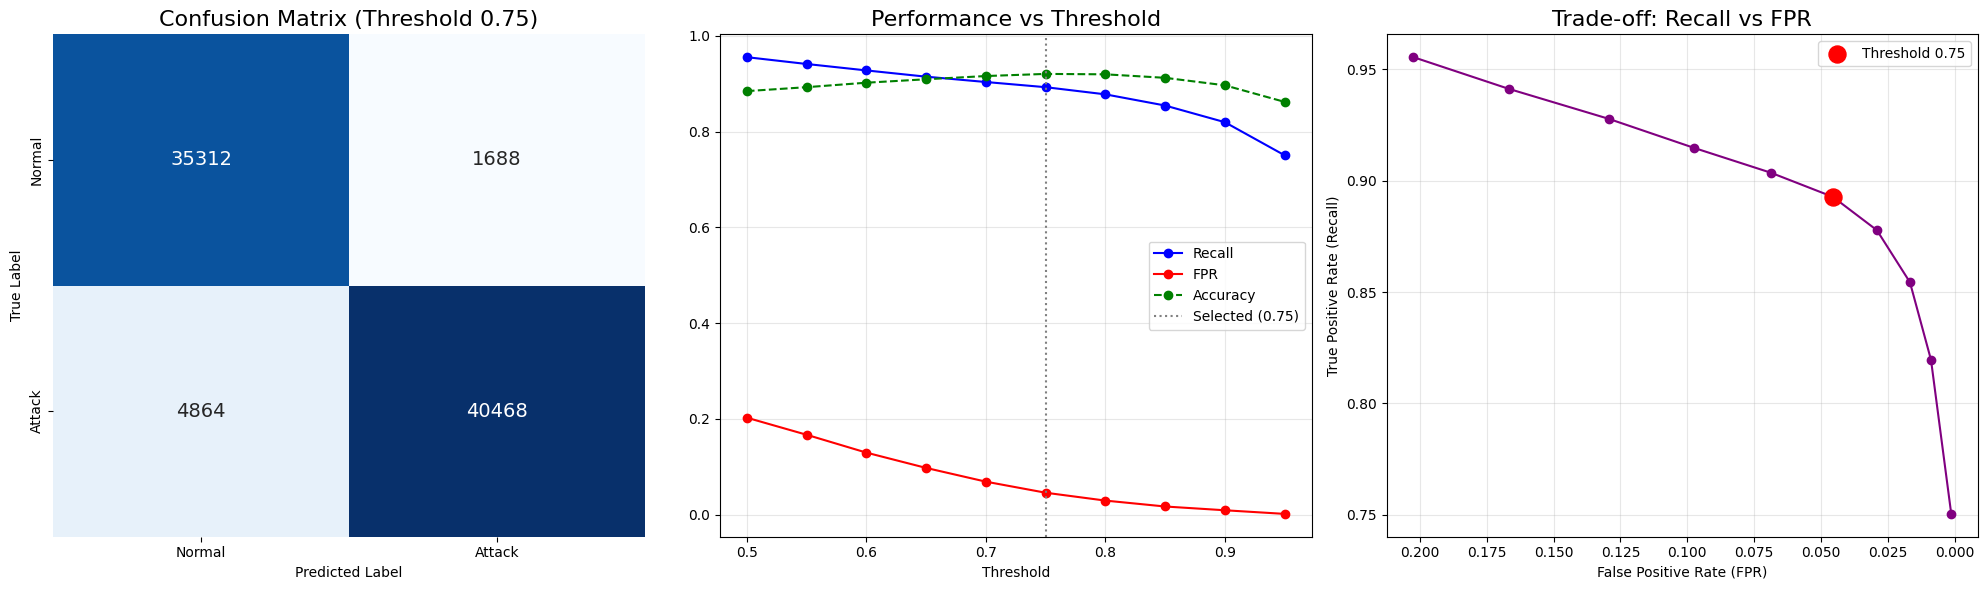

In [ ]:
# ---------------------------------------------------------
# 3. Execution Part
# ---------------------------------------------------------

# Instantiation
gwo = GreyWolfOptimisation(
    n_wolves=15,     
    max_iter=50,     
    random_state=42
)

# Optimize Execution
start_time_gwo = time.time()
best_mask_gwo = gwo.optimise(x_train_opt, y_train_opt, x_val_opt, y_val_opt)
print(f"Grey Wolf Optimisation execution finished in: {time.time() - start_time_gwo}")

# Mask Transformation
selected_features_gwo = best_mask_gwo == 1
print(f"Final Selected number of Features: {selected_features_gwo.sum()}")


# ---------------------------------------------------------
# 4. Final Model Training & Threshold Adjustment (Standard)
# ---------------------------------------------------------

# Train the final model using the entire dataset
x_train_final = x_train_scaled_full[:, selected_features_gwo]
x_test_final = x_test_scaled[:, selected_features_gwo]

final_rf_gwo = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining the final model...")
start_time = time.time()
final_rf_gwo.fit(x_train_final, y_train_full)
print(f"time: {time.time() - start_time}s")

# Retrieving the prediction probability
y_probs_gwo = final_rf_gwo.predict_proba(x_test_final)[:, 1]


# ---------------------------------------------------------
# 5. Visualization & Trade-off Analysis
# ---------------------------------------------------------
print(f"\n[Threshold Adjustment Results (GWO)]")
print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10} {'F1':<10}")
print("-" * 55)

threshold_list = []
fpr_list = []
recall_list = []
accuracy_list = []

# 0.5 -> 0.95
for thr in np.arange(0.5, 0.96, 0.05):
    y_pred_thr = (y_probs_gwo >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    TN, FP, FN, TP = cm.ravel()
    
    fpr = FP / (FP + TN)
    rec = TP / (TP + FN)
    acc = accuracy_score(y_test, y_pred_thr)
    
    f1 = f1_score(y_test, y_pred_thr, zero_division=0)
    mark = "★" if fpr < 0.15 else ""
    print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {f1:<10.4f} {mark}")
    
    threshold_list.append(thr)
    fpr_list.append(fpr)
    recall_list.append(rec)
    accuracy_list.append(acc)

# Plotting Graphs
# Automatically select the threshold that maximizes the F1 score (use the optimal threshold instead of a fixed value of 0.75)
f1_scores_thr = []
for thr_tmp in np.arange(0.3, 0.96, 0.05):
    y_tmp = (y_probs_gwo >= thr_tmp).astype(int)
    f1_scores_thr.append(f1_score(y_test, y_tmp, zero_division=0))
SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
print(f"Optimal Threshold (Max F1): {SELECTED_THRESHOLD}")
y_final_pred = (y_probs_gwo >= SELECTED_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_final_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Confusion Matrix (Threshold {SELECTED_THRESHOLD})', fontsize=16)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_yticklabels(['Normal', 'Attack'])

# 2. Threshold Performance
axes[1].plot(threshold_list, recall_list, marker='o', label='Recall', color='blue')
axes[1].plot(threshold_list, fpr_list, marker='o', label='FPR', color='red')
axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':', label=f'Selected ({SELECTED_THRESHOLD})')
axes[1].set_title('Performance vs Threshold', fontsize=16)
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Trade-off (Recall vs FPR)
axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5, label=f'Threshold {SELECTED_THRESHOLD}')
axes[2].set_title('Trade-off: Recall vs FPR', fontsize=16)
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

## 4.3. GWO + Optuna

[I 2026-03-14 18:31:01,168] A new study created in memory with name: no-name-fe5e5402-ac9b-40d8-973e-1affa34b9d57


--- GWO + Optuna: Hyperparameter Tuning Start ---


[I 2026-03-14 18:31:06,103] Trial 0 finished with value: 0.9089378810255321 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9089378810255321.
[I 2026-03-14 18:31:08,061] Trial 1 finished with value: 0.9077853398294018 and parameters: {'n_estimators': 64, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.9089378810255321.
[I 2026-03-14 18:31:15,831] Trial 2 finished with value: 0.9085511594306918 and parameters: {'n_estimators': 258, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.9089378810255321.
[I 2026-03-14 18:31:20,737] Trial 3 finished with value: 0.9081810656785221 and parameters: {'n_estimators': 158, 'max_depth': 21, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.908937881025


Best Params: {'n_estimators': 287, 'max_depth': 32, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
Best F1 Score (Validation): 0.9097

【GWO + Optuna 最終評価結果】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.1988     0.9539     0.8853     0.9015     
0.55       0.1619     0.9411     0.8948     0.9079     
0.60       0.1270     0.9273     0.9029     0.9131     ★
0.65       0.0947     0.9149     0.9106     0.9185     ★
0.70       0.0658     0.9032     0.9171     0.9231     ★
0.75       0.0429     0.8913     0.9208     0.9254     ★
0.80       0.0269     0.8758     0.9195     0.9229     ★
0.85       0.0152     0.8510     0.9111     0.9134     ★
0.90       0.0072     0.8175     0.8963     0.8967     ★
0.95       0.0011     0.7453     0.8593     0.8536     ★
最適閾値 (F1最大): 0.75


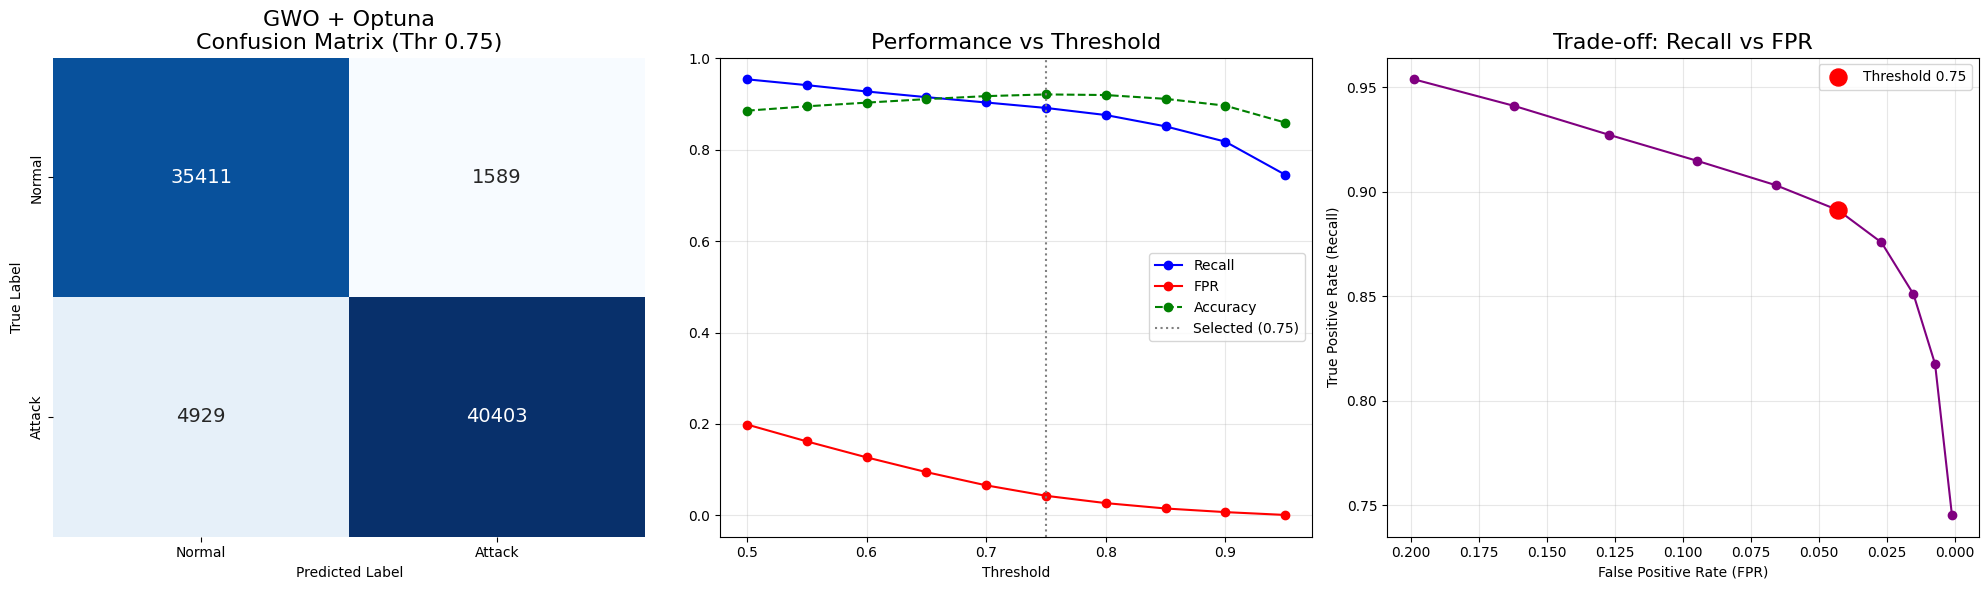

In [18]:
ALGORITHM_NAME = "GWO + Optuna"
TARGET_MASK    = selected_features_gwo

best_model_opt, x_test_opt = run_optuna_optimization(
    TARGET_MASK,
    x_train_opt, y_train_opt,           # Same data as for feature selection
    x_train_scaled_full, y_train_full,  # Data for final training
    x_test_scaled, y_test,
    ALGORITHM_NAME
)

y_probs_opt = best_model_opt.predict_proba(x_test_opt)[:, 1]
evaluate_and_plot(y_probs_opt, y_test, ALGORITHM_NAME)

# 5. Particle Swarm Optimisaion

## 5.1. PSO Implementation

In [19]:
# ============================
# Particle Swarm Optimisation (PSO) for Feature Selection
#
# Concept:
#   Each particle represents a candidate feature subset.
#   Particles move through the continuous search space guided by:
#     - Their own best position found so far (cognitive component, c1)
#     - The global best position found by any particle (social component, c2)
#     - Inertia from the previous velocity (w)
#
# Binary conversion:
#   Velocity is mapped to probability via sigmoid: P(bit=1) = σ(v_i)
#   A random draw determines the binary value each iteration.
#
# Design notes:
#   - Minimum 5 features per particle prevents degenerate all-zero solutions.
#   - Inertia weight w=0.9 is relatively high (emphasises exploration);
#     lower w (0.4–0.6) would shift toward exploitation.
#   - c1=2.0 > c2=1.0: particles trust their own experience more than the swarm,
#     which helps maintain diversity in the binary feature space.
# ============================

class ParticleSwarmOptimisation:
    def __init__(self, n_particles=20, n_iterations=30, w=0.9, c1=2.0, c2=1.0, random_state=42):
        self.n_particles  = n_particles
        self.n_iterations = n_iterations
        self.w            = w    # Inertia weight: momentum of previous velocity
        self.c1           = c1   # Cognitive coefficient: trust in personal best
        self.c2           = c2   # Social coefficient: trust in global best
        self.random_state = random_state

        self.best_solution   = None
        self.best_fitness    = -np.inf
        self.fitness_history = []

    def _sigmoid(self, x):
        """Standard sigmoid: maps velocity to probability P(bit=1)."""
        return 1 / (1 + np.exp(-x))

    def fitness_function(self, feature_mask, x_train, y_train, x_val, y_val):
        return fitness_function(feature_mask, x_train, y_train, x_val, y_val)
        
    def optimise(self, x_train, y_train, x_val, y_val):
        """
        Main PSO loop.
        Each iteration:
          1. Evaluate each particle's binary position.
          2. Update personal and global bests.
          3. Update velocities: v = w*v + c1*r1*(pbest-pos) + c2*r2*(gbest-pos)
          4. Binarise new positions via sigmoid + stochastic threshold.
          5. Repair: ensure at least 5 features selected per particle.
        """
        # Reset state for reproducibility
        self.rng = np.random.default_rng(self.random_state)
        self.best_fitness    = -np.inf
        self.best_solution   = None
        self.fitness_history = []

        n_features = x_train.shape[1]

        print(f"PSO Start: particles={self.n_particles}, iter={self.n_iterations}")
        print(f"w={self.w}, c1={self.c1}, c2={self.c2}")
        print(f"Number of Features: {n_features}")

        start_time = time.time()

        # Initialise binary positions (50% chance per feature) and repair sparse solutions
        positions  = (self.rng.random((self.n_particles, n_features)) < 0.5).astype(int)
        for i in range(self.n_particles):
            if positions[i].sum() < 5:  # Minimum 5 features to avoid trivial subsets
                positions[i, self.rng.choice(n_features, 5, replace=False)] = 1

        # Initialise velocities uniformly in [-1, 1]
        velocities = self.rng.uniform(-1, 1, (self.n_particles, n_features))

        personal_best_pos     = positions.copy()
        personal_best_fitness = np.full(self.n_particles, -np.inf)

        global_best_pos     = None
        global_best_fitness = -np.inf

        for iteration in range(self.n_iterations):
            # --- Evaluate & update bests ---
            for i in range(self.n_particles):
                fit = self.fitness_function(positions[i], x_train, y_train, x_val, y_val)

                if fit > personal_best_fitness[i]:
                    personal_best_fitness[i] = fit
                    personal_best_pos[i]     = positions[i].copy()

                if fit > global_best_fitness:
                    global_best_fitness    = fit
                    global_best_pos        = positions[i].copy()
                    self.best_solution     = positions[i].copy()
                    self.best_fitness      = fit

            # --- Velocity update (vectorised over all particles simultaneously) ---
            r1 = self.rng.random((self.n_particles, n_features))
            r2 = self.rng.random((self.n_particles, n_features))

            cognitive  = self.c1 * r1 * (personal_best_pos - positions)  # Pull toward own best
            social     = self.c2 * r2 * (global_best_pos   - positions)  # Pull toward swarm best
            velocities = self.w * velocities + cognitive + social

            # --- Position update: velocity → probability → binary ---
            probs     = self._sigmoid(velocities)
            positions = (self.rng.random((self.n_particles, n_features)) < probs).astype(int)

            # Repair: enforce minimum feature count
            for i in range(self.n_particles):
                if positions[i].sum() < 5:
                    positions[i, self.rng.choice(n_features, 5, replace=False)] = 1

            self.fitness_history.append(global_best_fitness)

            if (iteration + 1) % 5 == 0:
                print(f"Iter {iteration+1}: Best Fitness = {global_best_fitness:.4f}, Features = {self.best_solution.sum()}")

        total_time = time.time() - start_time
        print(f"PSO Complete: {total_time:.2f}s, Best Fitness: {self.best_fitness:.4f}")

        return self.best_solution

print("✓ ParticleSwarmOptimisation class loaded")


✓ ParticleSwarmOptimisation class loaded


## 5.2. PSO execution

PSO開始: particles=20, iter=30
w=0.9, c1=2.0, c2=1.0
特徴量数: 194
Iter 5: Best Fitness = 0.9603, Features = 97
Iter 10: Best Fitness = 0.9610, Features = 100
Iter 15: Best Fitness = 0.9618, Features = 94
Iter 20: Best Fitness = 0.9618, Features = 94
Iter 25: Best Fitness = 0.9618, Features = 94
Iter 30: Best Fitness = 0.9618, Features = 102
PSO完了: 2671.62秒, Best Fitness: 0.9618
Particle Swarm Optimisation execution finished in: 2671.6228382587433
最終選択特徴量数: 102

最終モデル学習中...
time: 12.81s

【閾値調整結果 (PSO)】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.1851     0.9522     0.8905     0.9054     
0.55       0.1475     0.9396     0.9005     0.9122     ★
0.60       0.1157     0.9270     0.9078     0.9172     ★
0.65       0.0833     0.9144     0.9154     0.9225     ★
0.70       0.0584     0.9044     0.9211     0.9266     ★
0.75       0.0369     0.8911     0.9235     0.9277     ★
0.80       0.0210     0.8706     0.9193     0.

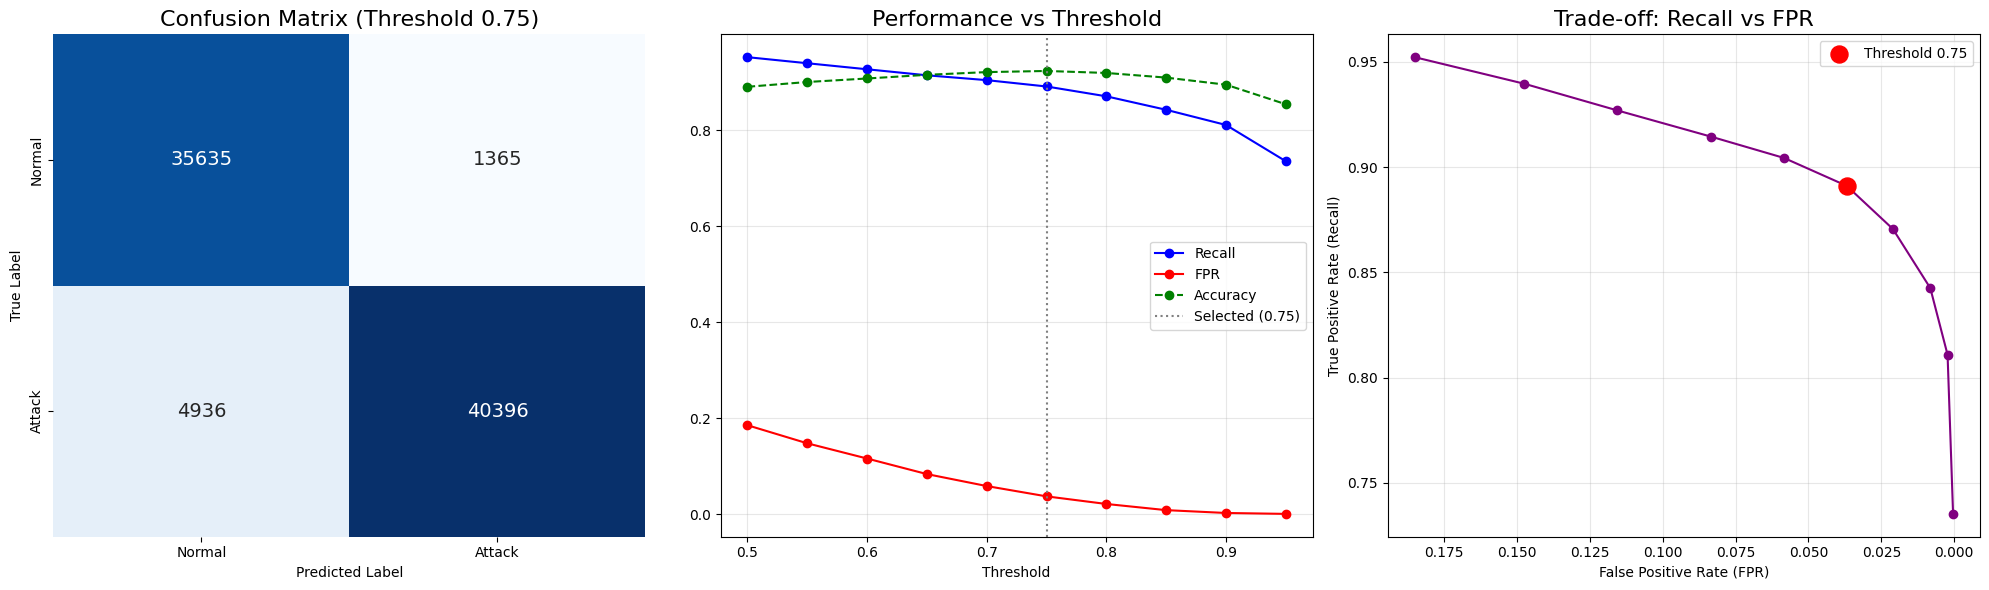

In [ ]:
# ---------------------------------------------------------
# 3. Execution Part
# ---------------------------------------------------------

pso = ParticleSwarmOptimisation(
    n_particles=20,
    n_iterations=30,
    w=0.9,
    c1=2.0,
    c2=1.0,
    random_state=42
)

start_time_pso = time.time()
best_mask_pso = pso.optimise(x_train_opt, y_train_opt, x_val_opt, y_val_opt)
print(f"Particle Swarm Optimisation execution finished in: {time.time() - start_time_pso}")

# Mask Transformation
selected_features_pso = best_mask_pso == 1
print(f"Final Selected number of Features: {selected_features_pso.sum()}")


# ---------------------------------------------------------
# 4. Final model training & threshold adjustment
# ---------------------------------------------------------

x_train_final = x_train_scaled_full[:, selected_features_pso]
x_test_final  = x_test_scaled[:, selected_features_pso]

final_rf_pso = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining the final model...")
start_time = time.time()
final_rf_pso.fit(x_train_final, y_train_full)
print(f"time: {time.time() - start_time:.2f}s")

y_probs_pso = final_rf_pso.predict_proba(x_test_final)[:, 1]

# ---------------------------------------------------------
# 5. Visualization & Trade-off Analysis
# ---------------------------------------------------------
print(f"\n[Threshold Adjustment Results (PSO)]")
print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10} {'F1':<10}")
print("-" * 55)

threshold_list = []
fpr_list       = []
recall_list    = []
accuracy_list  = []

for thr in np.arange(0.5, 0.96, 0.05):
    y_pred_thr = (y_probs_pso >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    TN, FP, FN, TP = cm.ravel()
    fpr = FP / (FP + TN)
    rec = TP / (TP + FN)
    acc = accuracy_score(y_test, y_pred_thr)
    f1  = f1_score(y_test, y_pred_thr, zero_division=0)
    mark = "★" if fpr < 0.15 else ""
    print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {f1:<10.4f} {mark}")
    threshold_list.append(thr)
    fpr_list.append(fpr)
    recall_list.append(rec)
    accuracy_list.append(acc)

# Automatically select the threshold at which F1 is maximized
f1_scores_thr = []
for thr_tmp in np.arange(0.3, 0.96, 0.05):
    y_tmp = (y_probs_pso >= thr_tmp).astype(int)
    f1_scores_thr.append(f1_score(y_test, y_tmp, zero_division=0))
SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
print(f"Optimal Threshold (Max F1): {SELECTED_THRESHOLD}")
y_final_pred = (y_probs_pso >= SELECTED_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_final_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Confusion Matrix (Threshold {SELECTED_THRESHOLD})', fontsize=16)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_yticklabels(['Normal', 'Attack'])

axes[1].plot(threshold_list, recall_list,   marker='o', label='Recall',   color='blue')
axes[1].plot(threshold_list, fpr_list,      marker='o', label='FPR',      color='red')
axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':', label=f'Selected ({SELECTED_THRESHOLD})')
axes[1].set_title('Performance vs Threshold', fontsize=16)
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5, label=f'Threshold {SELECTED_THRESHOLD}')
axes[2].set_title('Trade-off: Recall vs FPR', fontsize=16)
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()


## 5.3. PSO + Optuna

--- PSO + Optuna: Hyperparameter Tuning Start ---


[I 2026-03-14 19:18:26,010] A new study created in memory with name: no-name-d67e0c5e-6d21-42fa-9035-07670d420a8a
[I 2026-03-14 19:18:31,074] Trial 0 finished with value: 0.8931654392782475 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8931654392782475.
[I 2026-03-14 19:18:32,924] Trial 1 finished with value: 0.8911413658470282 and parameters: {'n_estimators': 64, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.8931654392782475.
[I 2026-03-14 19:18:40,313] Trial 2 finished with value: 0.8906469665575911 and parameters: {'n_estimators': 258, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.8931654392782475.
[I 2026-03-14 19:18:45,054] Trial 3 finished with value: 0.8920033589903834 and parameters: {'n_estimators': 158, 'max_depth': 21, '


Best Params: {'n_estimators': 277, 'max_depth': 35, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
Best F1 Score (Validation): 0.8939

【PSO + Optuna 最終評価結果】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.1845     0.9524     0.8909     0.9058     
0.55       0.1474     0.9390     0.9002     0.9120     ★
0.60       0.1146     0.9264     0.9080     0.9173     ★
0.65       0.0808     0.9139     0.9162     0.9232     ★
0.70       0.0573     0.9031     0.9209     0.9263     ★
0.75       0.0354     0.8888     0.9228     0.9269     ★
0.80       0.0178     0.8671     0.9188     0.9216     ★
0.85       0.0060     0.8364     0.9072     0.9085     ★
0.90       0.0016     0.7988     0.8885     0.8875     ★
0.95       0.0003     0.7116     0.8411     0.8314     ★
最適閾値 (F1最大): 0.75


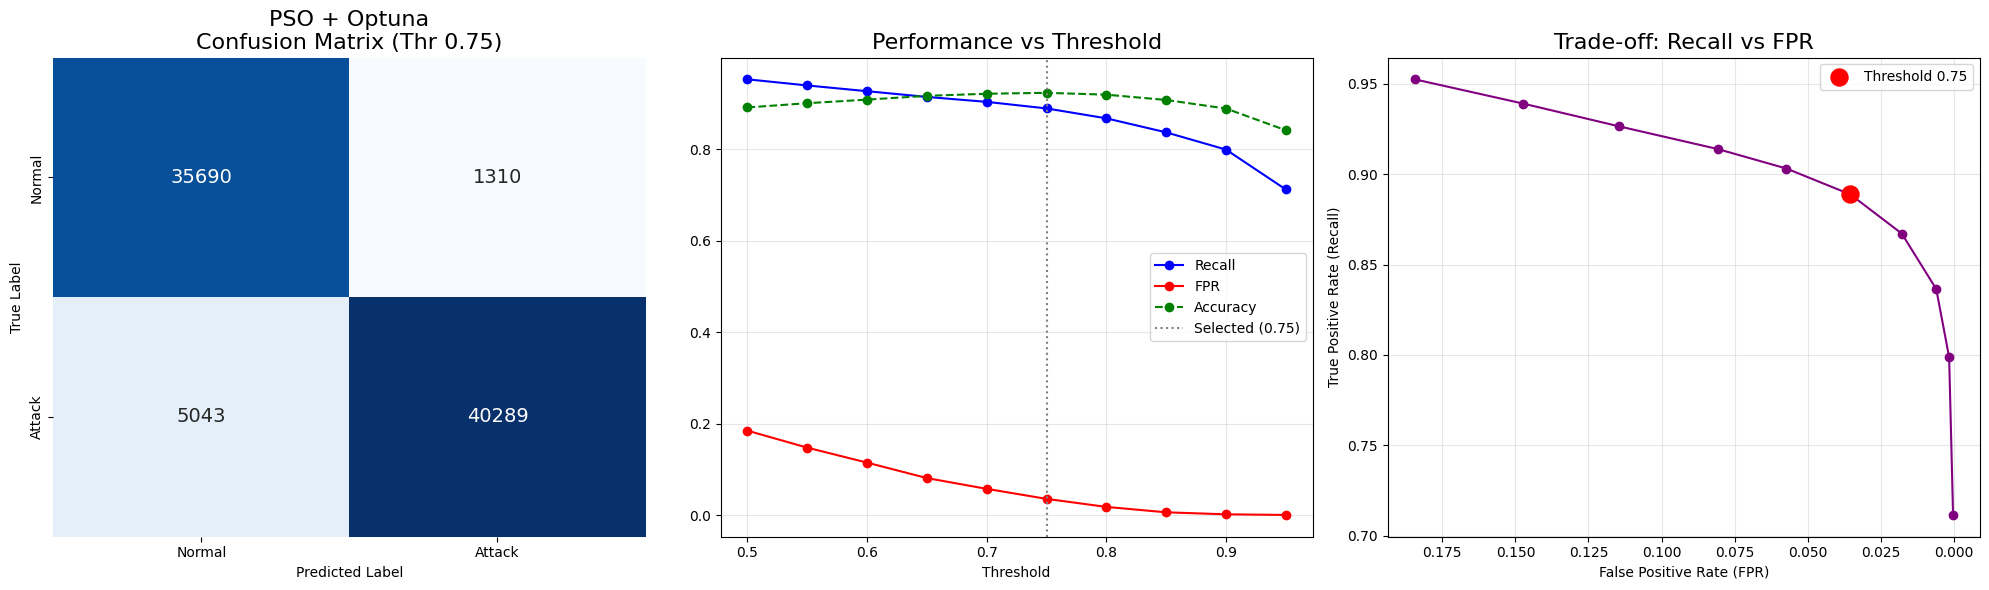

In [21]:
ALGORITHM_NAME = "PSO + Optuna"
TARGET_MASK    = selected_features_pso

best_model_opt, x_test_opt = run_optuna_optimization(
    TARGET_MASK,
    x_train_opt, y_train_opt,           # Same data as for feature selection
    x_train_scaled_full, y_train_full,  # Data for final training
    x_test_scaled, y_test,
    ALGORITHM_NAME
)

y_probs_opt = best_model_opt.predict_proba(x_test_opt)[:, 1]
evaluate_and_plot(y_probs_opt, y_test, ALGORITHM_NAME)

# 6. Simulated Annealing

## 6.1. SA Implementation

In [22]:
# =============================================================================
# Simulated Annealing (SA) for Feature Selection
#
# Concept:
#   Inspired by the annealing process in metallurgy: at high temperature,
#   the system accepts worse solutions with some probability, allowing escape
#   from local optima. As temperature decreases, acceptance probability falls
#   and the search converges toward the best solution found.
#
# Acceptance criterion (Metropolis):
#   Always accept improvements (Δfitness > 0).
#   Accept worse solutions with probability exp(Δfitness / T).
#
# Adaptive neighbourhood:
#   At high temperature (early): flip 3–10 bits (large moves, wide exploration)
#   At medium temperature:      flip 2–5 bits
#   At low temperature (late):  flip 1–2 bits (fine-grained local search)
#   This avoids the problem of a fixed flip size that is too large at the end.
#
# Initialisation:
#   Sparse initial solution (20% selected) avoids strong local optima from
#   starting with too many features.
#
# Cooling schedule:
#   Geometric cooling: T ← T * cooling_rate  each iteration
#   With temp=10, cooling=0.995, iter=800: final temp ≈ 0.49  (gradual)
# =============================================================================
class SimulatedAnnealing:
    def __init__(self, max_iter=600, temp=100, cooling_rate=0.99, random_state=42):
        self.max_iter = max_iter
        self.initial_temp = temp  # Store initial temp separately for reset
        self.temp = temp
        self.cooling_rate = cooling_rate
        self.random_state = random_state

        self.best_solution = None
        self.best_fitness = -np.inf
        self.fitness_history = []

    def fitness_function(self, individual, x_train, y_train, x_test, y_test):        
        return fitness_function(individual, x_train, y_train, x_test, y_test)
        
    def optimise(self, x_train, y_train, x_test, y_test):
        """Main SA loop with adaptive neighbourhood and Metropolis acceptance."""
        # Reset state (allows re-running the same SA object cleanly)
        self.rng = np.random.default_rng(self.random_state)
        self.temp = self.initial_temp
        self.best_fitness = -np.inf
        self.best_solution = None
        self.fitness_history = []
        
        n_features = x_train.shape[1]
        
        print(f"SA Start: iter={self.max_iter}, temp={self.temp}, cooling={self.cooling_rate}")
        print(f"Number of Features: {n_features}")
        
        start_time = time.time()

        # Sparse initialisation (20% selected) — reduces risk of large-feature local optima
        #current_solution = np.random.randint(0, 2, n_features)  # (alternative: dense random init)
        current_solution = self.rng.choice([0,1], size=n_features, p=[0.8,0.2])
        if current_solution.sum() == 0:  # Feasibility repair
            current_solution[self.rng.integers(0, n_features)] = 1
            
        current_fitness = self.fitness_function(current_solution, x_train, y_train, x_test, y_test)

        # Initialise best with the starting solution
        self.best_solution = current_solution.copy()
        self.best_fitness = current_fitness

        temp_max = self.temp  # Reference for adaptive flip ratio
        
        for i in range(self.max_iter):            
            # --- Adaptive neighbourhood: flip count depends on temperature ---
            temp_ratio = self.temp / temp_max
            n_selected = current_solution.sum()
            
            if temp_ratio > 0.6:       # High temperature: coarse exploration
                n_flip = int(np.clip(n_selected * 0.2, 3, 10))
            elif temp_ratio > 0.3:     # Medium temperature
                n_flip = int(np.clip(n_selected * 0.1, 2, 5))
            else:                      # Low temperature: fine-grained local search
                n_flip = self.rng.integers(1, 3)

            # Generate neighbour by flipping n_flip randomly chosen bits
            # Note: neighbour is generated from best_solution (not current) for stability
            neighbor = self.best_solution.copy()
            flip_indexs = self.rng.choice(n_features, n_flip, replace=False)
            neighbor[flip_indexs] = 1 - neighbor[flip_indexs]

            # Feasibility repair
            if neighbor.sum() == 0:
                neighbor[self.rng.integers(0, n_features)] = 1
                
            neighbor_fitness = self.fitness_function(neighbor, x_train, y_train, x_test, y_test)

            # --- Metropolis acceptance criterion ---
            diff = neighbor_fitness - current_fitness
            
            # Accept: always if improvement; probabilistically if worse
            if diff > 0 or self.rng.random() < math.exp(diff / self.temp):
                current_solution = neighbor
                current_fitness = neighbor_fitness

                if current_fitness > self.best_fitness:
                    self.best_fitness = current_fitness
                    self.best_solution = current_solution.copy()

            # Geometric cooling: temperature decreases each iteration
            self.temp *= self.cooling_rate
            self.fitness_history.append(self.best_fitness)

            if (i + 1) % 50 == 0 or i == 0:
                print(f"Iter {i+1}: Best Fitness = {self.best_fitness:.4f}, "
                      f"Current Fitness = {current_fitness:.4f}, " 
                      f"Temp = {self.temp:.4f}, "
                      f"n_flip = {n_flip}, "                       
                      f"Best Features = {self.best_solution.sum()}, "
                      f"Current Features = {current_solution.sum()}")

        
        total_time = time.time() - start_time
        print(f"SA Complete: {total_time:.2f}s, Best Fitness: {self.best_fitness:.4f}")
        
        return self.best_solution


## 6.2. SA execution

SA開始: iter=800, temp=10.0, cooling=0.995
特徴量数: 194
Iter 1: Best Fitness = 0.9573, Current Fitness = 0.9573, Temp = 9.9500, n_flip = 6, Best Features = 38, Current Features = 38
Iter 50: Best Fitness = 0.9594, Current Fitness = 0.9593, Temp = 7.7831, n_flip = 10, Best Features = 73, Current Features = 77
Iter 100: Best Fitness = 0.9606, Current Fitness = 0.9590, Temp = 6.0577, n_flip = 10, Best Features = 85, Current Features = 89
Iter 150: Best Fitness = 0.9621, Current Fitness = 0.9612, Temp = 4.7148, n_flip = 5, Best Features = 88, Current Features = 83
Iter 200: Best Fitness = 0.9621, Current Fitness = 0.9608, Temp = 3.6696, n_flip = 5, Best Features = 88, Current Features = 87
Iter 250: Best Fitness = 0.9621, Current Fitness = 0.9610, Temp = 2.8561, n_flip = 1, Best Features = 88, Current Features = 87
Iter 300: Best Fitness = 0.9621, Current Fitness = 0.9613, Temp = 2.2229, n_flip = 2, Best Features = 88, Current Features = 88
Iter 350: Best Fitness = 0.9621, Current Fitness = 0.9

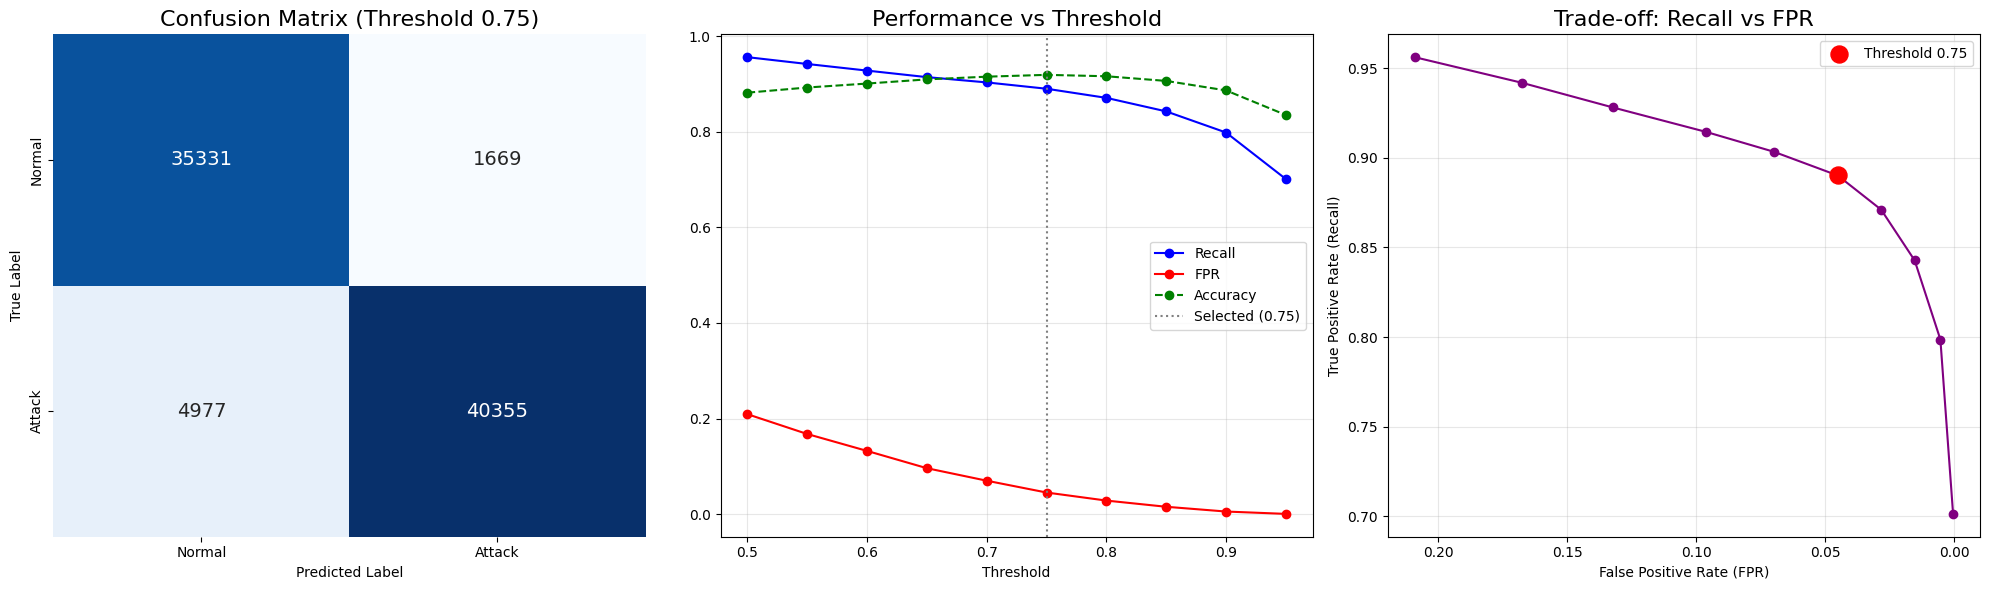

In [ ]:
# ---------------------------------------------------------
# 3. Execution Part
# ---------------------------------------------------------

# Instantiation
sa = SimulatedAnnealing(
    max_iter=800,
    temp=10.0,
    cooling_rate=0.995,
    random_state=42
)

# Optimize Execution
start_time_sa = time.time()
best_mask_sa = sa.optimise(x_train_opt, y_train_opt, x_val_opt, y_val_opt)
print(f"Simulated Annealing execution finished in: {time.time() - start_time_sa}")

# Mask Transformation
selected_features_sa = best_mask_sa == 1
print(f"Final Selected number of Features: {selected_features_sa.sum()}")


# ---------------------------------------------------------
# 4. Final Model Training & Threshold Adjustment (Standard)
# ---------------------------------------------------------

# Train the final model using the entire dataset
x_train_final = x_train_scaled_full[:, selected_features_sa]
x_test_final = x_test_scaled[:, selected_features_sa]

final_rf_sa = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining the final model...")
start_time = time.time()
final_rf_sa.fit(x_train_final, y_train_full)
print(f"time: {time.time() - start_time}s")

# Retrieving the prediction probability
y_probs_sa = final_rf_sa.predict_proba(x_test_final)[:, 1]


# ---------------------------------------------------------
# 5. Visualization & Trade-off Analysis
# ---------------------------------------------------------
print(f"\n[Threshold Adjustment Results (SA)]")
print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10} {'F1':<10}")
print("-" * 55)

threshold_list = []
fpr_list = []
recall_list = []
accuracy_list = []

# 0.5 -> 0.95
for thr in np.arange(0.5, 0.96, 0.05):
    y_pred_thr = (y_probs_sa >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    TN, FP, FN, TP = cm.ravel()
    
    fpr = FP / (FP + TN)
    rec = TP / (TP + FN)
    acc = accuracy_score(y_test, y_pred_thr)
    
    f1 = f1_score(y_test, y_pred_thr, zero_division=0) 
    mark = "★" if fpr < 0.15 else ""
    print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {f1:<10.4f} {mark}")
    
    threshold_list.append(thr)
    fpr_list.append(fpr)
    recall_list.append(rec)
    accuracy_list.append(acc)

# Plotting Graphs
# Automatically select the threshold that maximizes the F1 score (use the optimal threshold instead of a fixed value of 0.75)
f1_scores_thr = []
for thr_tmp in np.arange(0.3, 0.96, 0.05):
    y_tmp = (y_probs_sa >= thr_tmp).astype(int)
    f1_scores_thr.append(f1_score(y_test, y_tmp, zero_division=0))
SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
print(f"Optimal Threshold (Max F1): {SELECTED_THRESHOLD}")
y_final_pred = (y_probs_sa >= SELECTED_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_final_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Confusion Matrix (Threshold {SELECTED_THRESHOLD})', fontsize=16)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_yticklabels(['Normal', 'Attack'])

# 2. Threshold Performance
axes[1].plot(threshold_list, recall_list, marker='o', label='Recall', color='blue')
axes[1].plot(threshold_list, fpr_list, marker='o', label='FPR', color='red')
axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':', label=f'Selected ({SELECTED_THRESHOLD})')
axes[1].set_title('Performance vs Threshold', fontsize=16)
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Trade-off (Recall vs FPR)
axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5, label=f'Threshold {SELECTED_THRESHOLD}')
axes[2].set_title('Trade-off: Recall vs FPR', fontsize=16)
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

## 6.3. SA + optuna

--- SA + Optuna: Hyperparameter Tuning Start ---


[I 2026-03-14 20:14:12,022] A new study created in memory with name: no-name-9ae25524-668b-439b-a305-bd5ee0be7b77
[I 2026-03-14 20:14:16,637] Trial 0 finished with value: 0.8948207657407854 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8948207657407854.
[I 2026-03-14 20:14:18,409] Trial 1 finished with value: 0.8897244096501264 and parameters: {'n_estimators': 64, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.8948207657407854.
[I 2026-03-14 20:14:25,951] Trial 2 finished with value: 0.894330968112361 and parameters: {'n_estimators': 258, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.8948207657407854.
[I 2026-03-14 20:14:30,712] Trial 3 finished with value: 0.8954074708164743 and parameters: {'n_estimators': 158, 'max_depth': 21, 'm


Best Params: {'n_estimators': 245, 'max_depth': 24, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Best F1 Score (Validation): 0.8972

【SA + Optuna 最終評価結果】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.1977     0.9536     0.8856     0.9018     
0.55       0.1615     0.9402     0.8945     0.9075     
0.60       0.1282     0.9262     0.9017     0.9121     ★
0.65       0.0937     0.9129     0.9099     0.9177     ★
0.70       0.0665     0.9025     0.9164     0.9224     ★
0.75       0.0465     0.8907     0.9189     0.9237     ★
0.80       0.0298     0.8719     0.9161     0.9196     ★
0.85       0.0175     0.8458     0.9072     0.9094     ★
0.90       0.0055     0.8104     0.8931     0.8930     ★
0.95       0.0007     0.7312     0.8517     0.8445     ★
最適閾値 (F1最大): 0.75


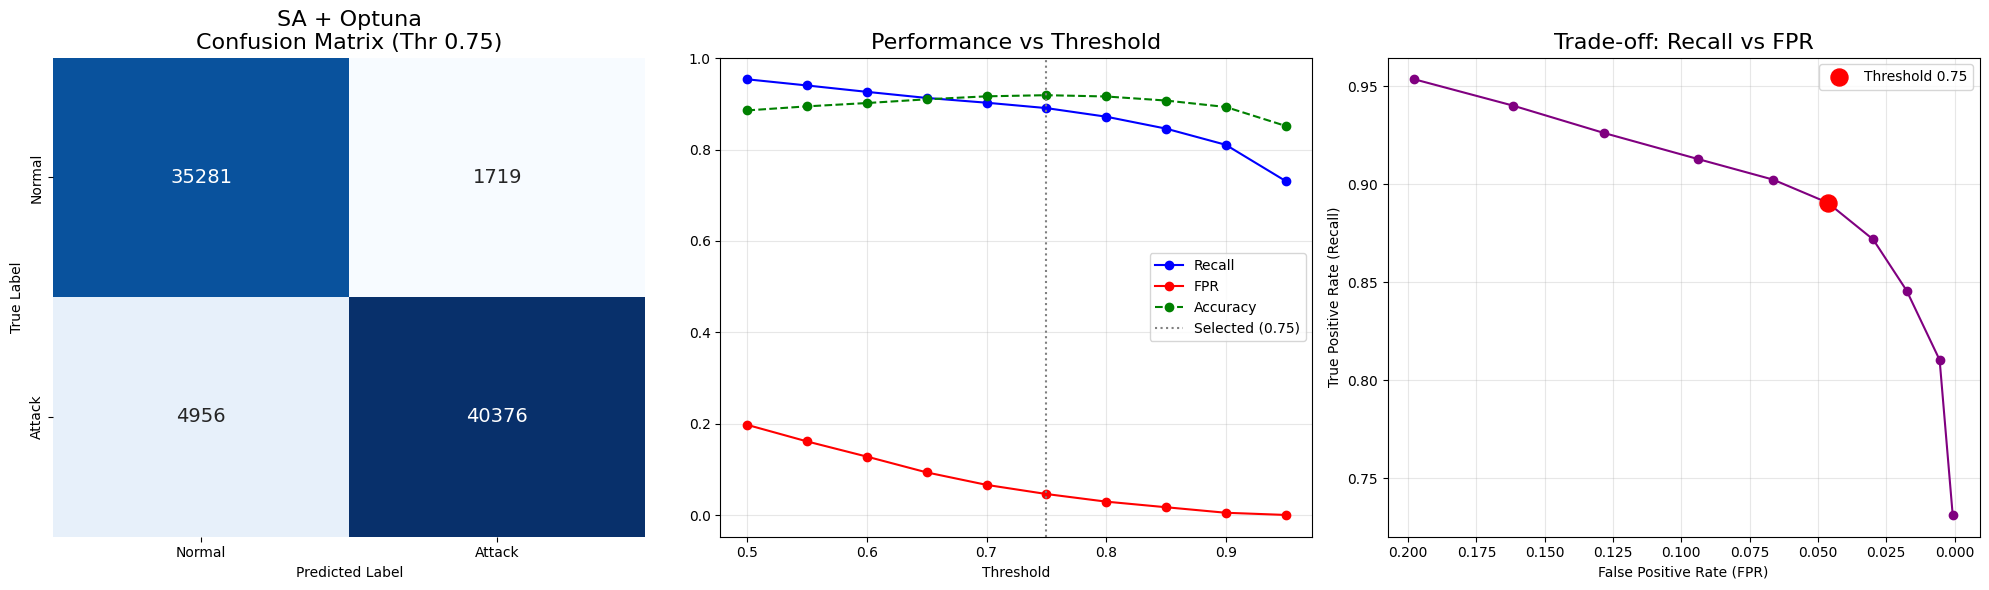

In [24]:
ALGORITHM_NAME = "SA + Optuna"
TARGET_MASK    = selected_features_sa

best_model_opt, x_test_opt = run_optuna_optimization(
    TARGET_MASK,
    x_train_opt, y_train_opt,           # Same data as for feature selection
    x_train_scaled_full, y_train_full,  # Data for final training
    x_test_scaled, y_test,
    ALGORITHM_NAME
)

y_probs_opt = best_model_opt.predict_proba(x_test_opt)[:, 1]
evaluate_and_plot(y_probs_opt, y_test, ALGORITHM_NAME)

# 7. Hybrid GWO-SA (Seq)

## 7.1. Hybrid GWO-SA Implementation

In [25]:
"""
Phase 1 (GWO): Wide-area search using swarm intelligence -> Identify the alpha wolf (optimal solution) from a diverse set of candidates
Phase 2 (SA): Local search using SA with the alpha wolf solution as the initial value -> Local optimization

Weakness of GWO alone: Due to noise from the conversion from continuous to binary space, the search around the optimal solution is coarse
Weakness of SA alone: Highly dependent on the quality of the initial solution; convergence is slow with random initialization
Strength of the hybrid approach: GWO provides a good initial solution, and SA refines it with precision
"""
from sklearn.metrics import roc_auc_score


class Hybrid_GWO_SA:
    def __init__(
        self, 
        # GWO params
        n_wolves=10, gwo_iter=20,
        # SA params
        sa_iter=800, initial_temp=10.0, cooling_rate=0.99,
        random_state=42
    ):

        self.n_wolves     = n_wolves
        self.gwo_iter     = gwo_iter
        self.sa_iter      = sa_iter
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.random_state = random_state

        self.best_solution   = None
        self.best_fitness    = -np.inf
        self.gwo_history     = []   # Best fitness history for the GWO phase
        self.sa_history      = []   # Best fitness history for the SA phase
        self.fitness_history = []   # Overall (GWO + SA combined)

    def fitness_function(self, individual, x_train, y_train, x_test, y_test):        
        return fitness_function(individual, x_train, y_train, x_test, y_test)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-10 * (x - 0.5)))
        

    # ------------------------------------------
    # Phase 1 : GWO
    # ------------------------------------------
    def gwo(self, x_train, y_train, x_test, y_test):
        n_features = x_train.shape[1]
        print(f"\nPhase 1 (GWO) : Wolves={self.n_wolves}, Iteration={self.gwo_iter}")

        wolves_pos = self.rng.random((self.n_wolves, n_features))

        alpha_pos, alpha_score = np.zeros(n_features), -np.inf
        beta_pos,  beta_score  = np.zeros(n_features), -np.inf
        delta_pos, delta_score = np.zeros(n_features), -np.inf

        for iteration in range(self.gwo_iter):
            for i in range(self.n_wolves):
                probs  = self._sigmoid(wolves_pos[i])
                binary = (self.rng.random(n_features) < probs).astype(int)
                if binary.sum() == 0:
                    binary[self.rng.integers(n_features)] = 1

                fit = self.fitness_function(binary, x_train, y_train, x_test, y_test)

                # Leader hierarchy update (alpha > beta > delta)
                if fit > alpha_score:
                    delta_score, delta_pos = beta_score, beta_pos.copy()
                    beta_score,  beta_pos  = alpha_score, alpha_pos.copy()
                    alpha_score, alpha_pos = fit, wolves_pos[i].copy()
                    self.best_solution = binary.copy()
                    self.best_fitness  = fit
                elif fit > beta_score:
                    delta_score, delta_pos = beta_score, beta_pos.copy()
                    beta_score,  beta_pos  = fit, wolves_pos[i].copy()
                elif fit > delta_score:
                    delta_score, delta_pos = fit, wolves_pos[i].copy()

            # a: Linear decay from 2 to 0
            a = 2 - iteration * (2 / self.gwo_iter)

            # Update the positions of each wolf (move them toward alpha, beta, and delta)
            for i in range(self.n_wolves):
                for leader_pos in [alpha_pos, beta_pos, delta_pos]:
                    r1, r2 = self.rng.random(n_features), self.rng.random(n_features)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D = np.abs(C * leader_pos - wolves_pos[i])
                    wolves_pos[i] = np.clip(leader_pos - A * D, 0, 1)

            self.gwo_history.append(self.best_fitness)

            if (iteration + 1) % 10 == 0 or iteration == 0:
                print(f"  GWO Iter {iteration+1:3d}/{self.gwo_iter}: "
                      f"Best Fitness={self.best_fitness:.4f}, "
                      f"Features={self.best_solution.sum()}")

        print(f"[GWO Phase  Complete] Best Fitness={self.best_fitness:.4f}, "
              f"Features={self.best_solution.sum()}")
        return self.best_solution.copy()



    # ------------------------------------------------------------------
    # Phase 2: SA 
    # ------------------------------------------------------------------
    def sa(self, initial_solution, x_train, y_train, x_test, y_test):
        print(f"\n[SA Phase] Iterations={self.sa_iter}, "
              f"T0={self.initial_temp}, Cooling={self.cooling_rate}")

        current_solution = initial_solution.copy()
        current_fit = self.fitness_function(current_solution, x_train, y_train, x_test, y_test)

        best_solution = current_solution.copy()
        best_fit = current_fit
        n_features = len(current_solution)
        temp = self.initial_temp

        temp_max = temp  # Record the initial temperature for Adaptive Flip

        for i in range(self.sa_iter):
            # Adaptive Neighborhood Generation
            # Moves in large steps during the early stages when the temperature is high (escaping local optima)
            # Moves in small steps during the late stages when the temperature is low (precise search)
            temp_ratio = temp / temp_max if temp_max > 1e-10 else 0.0
            n_selected = current_solution.sum()
            
            if temp_ratio > 0.6:
                n_flip = int(np.clip(n_selected * 0.2, 3, 10))
            elif temp_ratio > 0.3:
                n_flip = int(np.clip(n_selected * 0.1, 2, 5))
            else:
                n_flip = self.rng.integers(1, 3)

            neighbor = best_solution.copy()
            flip_idxs = self.rng.choice(n_features, n_flip, replace=False)
            neighbor[flip_idxs] = 1 - neighbor[flip_idxs]
            if neighbor.sum() == 0:
                neighbor[self.rng.integers(n_features)] = 1

            neighbor_fit = self.fitness_function(neighbor, x_train, y_train, x_test, y_test)

            # Metropolis Acceptance Criteria
            diff = neighbor_fit - current_fit
            if diff > 0 or (temp > 1e-10 and self.rng.random() < math.exp(diff / temp)):
                current_solution = neighbor
                current_fit = neighbor_fit

                if current_fit > best_fit:
                    best_fit = current_fit
                    best_solution = current_solution.copy()

            temp *= self.cooling_rate
            self.sa_history.append(best_fit)

            if (i + 1) % 100 == 0 or i == 0:
                print(f"  SA Iter {i+1:4d}/{self.sa_iter}: "
                      f"Best Fitness={best_fit:.4f}, "
                      f"Temp={temp:.4f}, "
                      f"Features={best_solution.sum()}")

        print(f"[SA Phase  Complete] Best Fitness={best_fit:.4f}, Features={best_solution.sum()}")
        return best_solution, best_fit


    # ------------------------------------------------------------------
    # Main Optimization
    # ------------------------------------------------------------------
    def optimise(self, x_train, y_train, x_test, y_test):
        #random.seed(self.random_state)        
        self.rng = np.random.default_rng(self.random_state)

        self.best_solution   = None
        self.best_fitness    = -np.inf
        self.gwo_history     = []
        self.sa_history      = []
        self.fitness_history = []

        n_features = x_train.shape[1]
        print(f"=== GWO+SA Hybrid  Start ===")
        print(f"Number of Features: {n_features}")
        start_time = time.time()

        # ---- Phase 1: GWO ----
        gwo_best = self.gwo(x_train, y_train, x_test, y_test)

        # ---- Phase 2: SA (GWO best → initial solution) ----
        sa_best, sa_fit = self.sa(gwo_best, x_train, y_train, x_test, y_test)

        # If SA further improves GWO, adopt the SA results
        if sa_fit > self.best_fitness:
            self.best_solution = sa_best
            self.best_fitness  = sa_fit

        # Combine overall fitness trends
        self.fitness_history = self.gwo_history + self.sa_history

        elapsed = time.time() - start_time
        print(f"\n=== GWO+SA Hybrid  Complete ===")
        print(f"Total execution time : {elapsed:.2f}s")
        print(f"Final Fitness: {self.best_fitness:.4f}")
        print(f"Selected number of Features: {self.best_solution.sum()} / {n_features}")

        return self.best_solution

## 7.2. Hybrid GWO-SA Execution

=== GWO+SA Hybrid 開始 ===
特徴量数: 194

Phase 1 (GWO) : Wolves=15, Iteration=20
  GWO Iter   1/20: Best Fitness=0.9602, Features=90
  GWO Iter  10/20: Best Fitness=0.9617, Features=86
  GWO Iter  20/20: Best Fitness=0.9617, Features=86
[GWO Phase 完了] Best Fitness=0.9617, Features=86

[SA Phase] Iterations=300, T0=2.0, Cooling=0.997
  SA Iter    1/300: Best Fitness=0.9617, Temp=1.9940, Features=86
  SA Iter  100/300: Best Fitness=0.9621, Temp=1.4810, Features=90
  SA Iter  200/300: Best Fitness=0.9621, Temp=1.0966, Features=90
  SA Iter  300/300: Best Fitness=0.9625, Temp=0.8120, Features=93
[SA Phase 完了] Best Fitness=0.9625, Features=93

=== GWO+SA Hybrid 完了 ===
総実行時間 : 2541.46秒
最終 Fitness: 0.9625
選択特徴量数: 93 / 194
Hybrid GWO-SA (seq) execution finished in: 2541.45854306221
最終選択特徴量数: 93


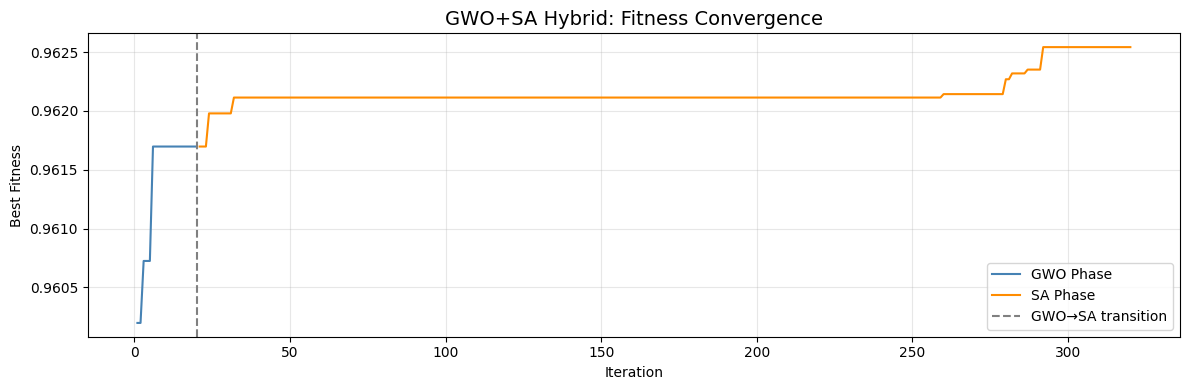


最終モデル学習中...
time: 12.60s

【閾値調整結果 (GWO+SA)】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.2044     0.9540     0.8828     0.8996     
0.55       0.1674     0.9419     0.8928     0.9063     
0.60       0.1341     0.9302     0.9013     0.9121     ★
0.65       0.1002     0.9187     0.9102     0.9185     ★
0.70       0.0702     0.9080     0.9178     0.9240     ★
0.75       0.0433     0.8920     0.9211     0.9257     ★
0.80       0.0249     0.8683     0.9163     0.9195     ★
0.85       0.0114     0.8335     0.9032     0.9046     ★
0.90       0.0039     0.8023     0.8894     0.8887     ★
0.95       0.0010     0.7437     0.8584     0.8526     ★
最適閾値 (F1最大): 0.75


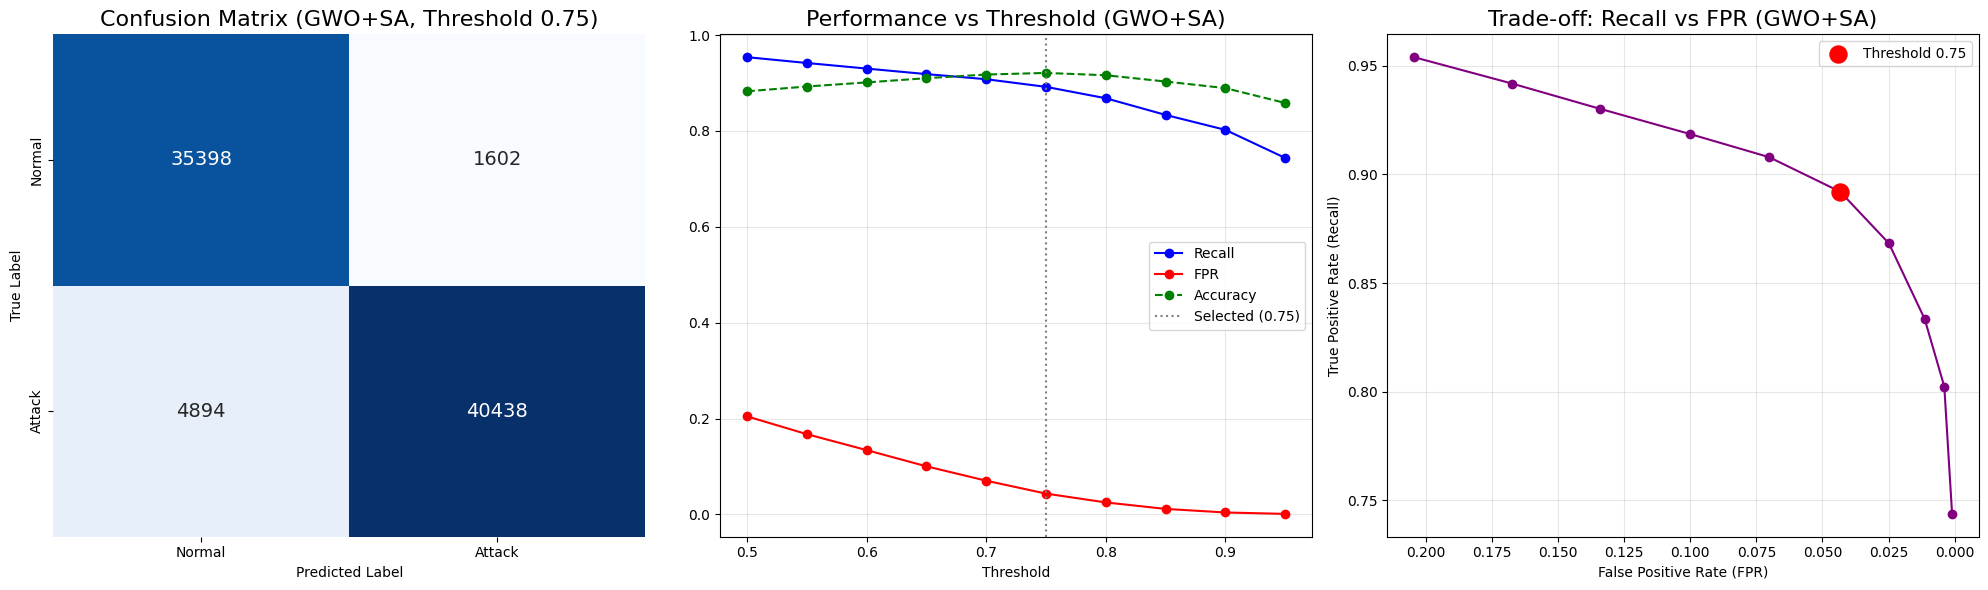

In [ ]:
# ---------------------------------------------------------
# 3. Execution Part
# ---------------------------------------------------------
gwo_sa = Hybrid_GWO_SA(
    n_wolves=15,
    gwo_iter=20,       # GWO: Wide-area search
    sa_iter=300,       # SA : Local search
    initial_temp=2.0,
    cooling_rate=0.997,
    random_state=42
)

start_time_hybrid1 = time.time()
best_mask_gwo_sa = gwo_sa.optimise(x_train_opt, y_train_opt, x_val_opt, y_val_opt)
print(f"Hybrid GWO-SA (seq) execution finished in: {time.time() - start_time_hybrid1}")

# Mask Transformation
selected_features_gwo_sa = best_mask_gwo_sa == 1
print(f"Final Selected number of Features: {selected_features_gwo_sa.sum()}")

# Visualizing Fitness Trends in the GWO vs. SA Phase
fig_conv, ax_conv = plt.subplots(figsize=(12, 4))
gwo_x = list(range(1, len(gwo_sa.gwo_history) + 1))
sa_x  = list(range(len(gwo_sa.gwo_history) + 1,
                   len(gwo_sa.gwo_history) + len(gwo_sa.sa_history) + 1))
ax_conv.plot(gwo_x, gwo_sa.gwo_history, color='steelblue', label='GWO Phase')
ax_conv.plot(sa_x,  gwo_sa.sa_history,  color='darkorange', label='SA Phase')
ax_conv.axvline(x=len(gwo_sa.gwo_history), color='gray', linestyle='--', label='GWO→SA transition')
ax_conv.set_title('GWO+SA Hybrid: Fitness Convergence', fontsize=14)
ax_conv.set_xlabel('Iteration')
ax_conv.set_ylabel('Best Fitness')
ax_conv.legend()
ax_conv.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Final model training & threshold adjustment
# ---------------------------------------------------------
x_train_final = x_train_scaled_full[:, selected_features_gwo_sa]
x_test_final  = x_test_scaled[:, selected_features_gwo_sa]

final_rf_gwo_sa = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining the final model...")
start_time = time.time()
final_rf_gwo_sa.fit(x_train_final, y_train_full)
print(f"time: {time.time() - start_time:.2f}s")

y_probs_gwo_sa = final_rf_gwo_sa.predict_proba(x_test_final)[:, 1]

# ---------------------------------------------------------
# 5. Visualization & Trade-off Analysis
# ---------------------------------------------------------
print(f"\n[Threshold Adjustment Results (GWO+SA)]")
print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10} {'F1':<10}")
print("-" * 55)

threshold_list = []
fpr_list       = []
recall_list    = []
accuracy_list  = []

for thr in np.arange(0.5, 0.96, 0.05):
    y_pred_thr = (y_probs_gwo_sa >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    TN, FP, FN, TP = cm.ravel()
    fpr = FP / (FP + TN)
    rec = TP / (TP + FN)
    acc = accuracy_score(y_test, y_pred_thr)
    f1  = f1_score(y_test, y_pred_thr, zero_division=0)
    mark = "★" if fpr < 0.15 else ""
    print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {f1:<10.4f} {mark}")
    threshold_list.append(thr)
    fpr_list.append(fpr)
    recall_list.append(rec)
    accuracy_list.append(acc)

f1_scores_thr = []
for thr_tmp in np.arange(0.3, 0.96, 0.05):
    y_tmp = (y_probs_gwo_sa >= thr_tmp).astype(int)
    f1_scores_thr.append(f1_score(y_test, y_tmp, zero_division=0))
SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
print(f"Optimal Threshold (Max F1): {SELECTED_THRESHOLD}")
y_final_pred = (y_probs_gwo_sa >= SELECTED_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_final_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Confusion Matrix (GWO+SA, Threshold {SELECTED_THRESHOLD})', fontsize=16)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_yticklabels(['Normal', 'Attack'])

axes[1].plot(threshold_list, recall_list,   marker='o', label='Recall',   color='blue')
axes[1].plot(threshold_list, fpr_list,      marker='o', label='FPR',      color='red')
axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':',
                label=f'Selected ({SELECTED_THRESHOLD})')
axes[1].set_title('Performance vs Threshold (GWO+SA)', fontsize=16)
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5,
                label=f'Threshold {SELECTED_THRESHOLD}')
axes[2].set_title('Trade-off: Recall vs FPR (GWO+SA)', fontsize=16)
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()


## 7.3. Hybrid GWO-SA + Optuna

--- Hybrid GWO-SA + Optuna: Hyperparameter Tuning Start ---


[I 2026-03-14 20:58:41,471] A new study created in memory with name: no-name-636ce104-ef76-47b6-85c8-9afea800d2fa
[I 2026-03-14 20:58:46,373] Trial 0 finished with value: 0.8976872610476854 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8976872610476854.
[I 2026-03-14 20:58:48,156] Trial 1 finished with value: 0.8959692195008224 and parameters: {'n_estimators': 64, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.8976872610476854.
[I 2026-03-14 20:58:55,499] Trial 2 finished with value: 0.8971532879762962 and parameters: {'n_estimators': 258, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.8976872610476854.
[I 2026-03-14 20:59:00,122] Trial 3 finished with value: 0.8970499009517308 and parameters: {'n_estimators': 158, 'max_depth': 21, '


Best Params: {'n_estimators': 164, 'max_depth': 42, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
Best F1 Score (Validation): 0.8981

【Hybrid GWO-SA + Optuna 最終評価結果】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.2008     0.9533     0.8840     0.9005     
0.55       0.1640     0.9413     0.8940     0.9072     
0.60       0.1306     0.9295     0.9025     0.9130     ★
0.65       0.0964     0.9167     0.9108     0.9188     ★
0.70       0.0646     0.9056     0.9190     0.9249     ★
0.75       0.0399     0.8882     0.9205     0.9248     ★
0.80       0.0210     0.8660     0.9168     0.9197     ★
0.85       0.0098     0.8311     0.9026     0.9038     ★
0.90       0.0033     0.7976     0.8870     0.8860     ★
0.95       0.0007     0.7345     0.8535     0.8467     ★
最適閾値 (F1最大): 0.7


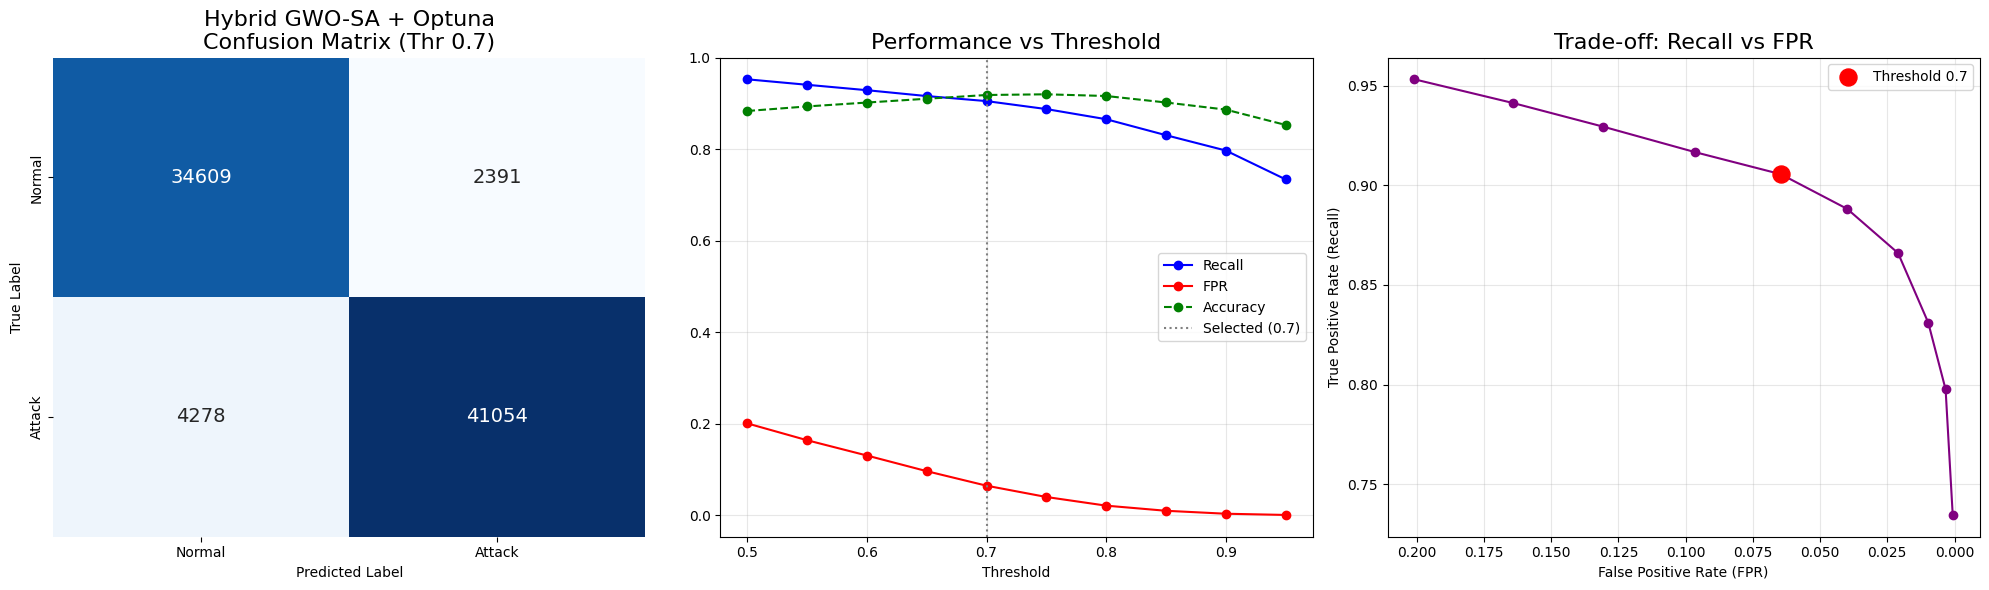

In [27]:
ALGORITHM_NAME = "Hybrid GWO-SA + Optuna"
TARGET_MASK    = selected_features_gwo_sa

best_model_opt, x_test_opt = run_optuna_optimization(
    TARGET_MASK,
    x_train_opt, y_train_opt,           # Same data as for feature selection
    x_train_scaled_full, y_train_full,  # Data for final training
    x_test_scaled, y_test,
    ALGORITHM_NAME
)

y_probs_opt = best_model_opt.predict_proba(x_test_opt)[:, 1]
evaluate_and_plot(y_probs_opt, y_test, ALGORITHM_NAME)

# 8. Hybrid GWO-SA (Embbed) (SA at each iteration of GWO)

In [28]:
"""
Phase 1 (GWO): Wide-area search using swarm intelligence -> Identify the alpha wolf (optimal solution) from a diverse set of candidates
Phase 2 (SA): Local search using SA with the alpha wolf solution as the initial value -> Local optimization

Weakness of GWO alone: Due to noise from the conversion from continuous to binary space, the search around the optimal solution is coarse
Weakness of SA alone: Highly dependent on the quality of the initial solution; convergence is slow with random initialization
Strength of the hybrid approach: GWO provides a good initial solution, and SA refines it with precision
"""
from sklearn.metrics import roc_auc_score


class Hybrid_GWO_SA2:
    def __init__(
        self, 
        # GWO params
        n_wolves=10, gwo_iter=20,
        # SA params
        sa_iter=800, initial_temp=10.0, cooling_rate=0.99,
        random_state=42
    ):

        self.n_wolves     = n_wolves
        self.gwo_iter     = gwo_iter
        self.sa_iter      = sa_iter
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.random_state = random_state

        self.best_solution   = None
        self.best_fitness    = -np.inf
        self.gwo_history     = []   # Best fitness history for the GWO phase
        self.sa_history      = []   # Best fitness history for the SA phase
        self.fitness_history = []   # Overall (GWO + SA combined)
        
    def fitness_function(self, individual, x_train, y_train, x_test, y_test):        
        return fitness_function(individual, x_train, y_train, x_test, y_test)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-10 * (x - 0.5)))
        

    # ------------------------------------------
    # Phase 1 : GWO (Execute SA after each iteration)
    # ------------------------------------------
    def gwo(self, x_train, y_train, x_test, y_test):
        n_features = x_train.shape[1]
        print(f"\nPhase 1 (GWO) : Wolves={self.n_wolves}, Iteration={self.gwo_iter}")

        wolves_pos = self.rng.random((self.n_wolves, n_features))

        alpha_pos, alpha_score = np.zeros(n_features), -np.inf
        beta_pos,  beta_score  = np.zeros(n_features), -np.inf
        delta_pos, delta_score = np.zeros(n_features), -np.inf

        for iteration in range(self.gwo_iter):
            for i in range(self.n_wolves):
                probs  = self._sigmoid(wolves_pos[i])
                binary = (self.rng.random(n_features) < probs).astype(int)
                if binary.sum() == 0:
                    binary[self.rng.integers(n_features)] = 1

                fit = self.fitness_function(binary, x_train, y_train, x_test, y_test)

                if fit > alpha_score:
                    delta_score, delta_pos = beta_score, beta_pos.copy()
                    beta_score,  beta_pos  = alpha_score, alpha_pos.copy()
                    alpha_score, alpha_pos = fit, wolves_pos[i].copy()
                    self.best_solution = binary.copy()
                    self.best_fitness  = fit
                elif fit > beta_score:
                    delta_score, delta_pos = beta_score, beta_pos.copy()
                    beta_score,  beta_pos  = fit, wolves_pos[i].copy()
                elif fit > delta_score:
                    delta_score, delta_pos = fit, wolves_pos[i].copy()

            a = 2 - iteration * (2 / self.gwo_iter)

            for i in range(self.n_wolves):
                for leader_pos in [alpha_pos, beta_pos, delta_pos]:
                    r1, r2 = self.rng.random(n_features), self.rng.random(n_features)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D = np.abs(C * leader_pos - wolves_pos[i])
                    wolves_pos[i] = np.clip(leader_pos - A * D, 0, 1)

            # ocally refine the alpha solution in SA after each GWO iteration
            sa_sol, sa_fit = self.sa(
                self.best_solution.copy(), x_train, y_train, x_test, y_test
            )
            if sa_fit > self.best_fitness:
                self.best_fitness  = sa_fit
                self.best_solution = sa_sol.copy()
                # Apply the improved solution from SA to the alpha position as well
                alpha_score = sa_fit
                alpha_pos   = sa_sol.astype(float)

            self.gwo_history.append(self.best_fitness)

            if (iteration + 1) % 10 == 0 or iteration == 0:
                print(f"  GWO Iter {iteration+1:3d}/{self.gwo_iter}: "
                      f"Best Fitness={self.best_fitness:.4f}, "
                      f"Features={self.best_solution.sum()}")

        print(f"[GWO Phase  Complete] Best Fitness={self.best_fitness:.4f}, "
              f"Features={self.best_solution.sum()}")
        return self.best_solution.copy()



    # ------------------------------------------------------------------
    # Phase 2: SA 
    # ------------------------------------------------------------------
    def sa(self, initial_solution, x_train, y_train, x_test, y_test):
        print(f"\n[SA Phase] Iterations={self.sa_iter}, "
              f"T0={self.initial_temp}, Cooling={self.cooling_rate}")

        current_solution = initial_solution.copy()
        current_fit = self.fitness_function(current_solution, x_train, y_train, x_test, y_test)

        best_solution = current_solution.copy()
        best_fit = current_fit
        n_features = len(current_solution)
        temp = self.initial_temp

        temp_max = temp  # Record the initial temperature for Adaptive Flip

        for i in range(self.sa_iter):
            # --- Adaptive Neighborhood Generation ---
            # Moves in large steps during the early stages when the temperature is high (to escape local optima)
            # Moves in small steps during the late stages when the temperature is low (for precise search)
            temp_ratio = temp / temp_max if temp_max > 1e-10 else 0.0
            n_selected = current_solution.sum()
            
            if temp_ratio > 0.6:
                n_flip = int(np.clip(n_selected * 0.2, 3, 10))
            elif temp_ratio > 0.3:
                n_flip = int(np.clip(n_selected * 0.1, 2, 5))
            else:
                n_flip = self.rng.integers(1, 3)

            neighbor = best_solution.copy()
            flip_idxs = self.rng.choice(n_features, n_flip, replace=False)
            neighbor[flip_idxs] = 1 - neighbor[flip_idxs]
            if neighbor.sum() == 0:
                neighbor[self.rng.integers(n_features)] = 1

            neighbor_fit = self.fitness_function(neighbor, x_train, y_train, x_test, y_test)

            # Metropolis Acceptance Criteria
            diff = neighbor_fit - current_fit
            if diff > 0 or (temp > 1e-10 and self.rng.random() < math.exp(diff / temp)):
                current_solution = neighbor
                current_fit = neighbor_fit

                if current_fit > best_fit:
                    best_fit = current_fit
                    best_solution = current_solution.copy()

            temp *= self.cooling_rate
            self.sa_history.append(best_fit)

            if (i + 1) % 10 == 0 or i == 0:
                print(f"  SA Iter {i+1:4d}/{self.sa_iter}: "
                      f"Best Fitness={best_fit:.4f}, "
                      f"Temp={temp:.4f}, "
                      f"Features={best_solution.sum()}")

        print(f"[SA Phase  Complete] Best Fitness={best_fit:.4f}, Features={best_solution.sum()}")
        return best_solution, best_fit


    # ------------------------------------------------------------------
    # Main Optimization
    # ------------------------------------------------------------------
    def optimise(self, x_train, y_train, x_test, y_test):      
        self.rng = np.random.default_rng(self.random_state)

        self.best_solution   = None
        self.best_fitness    = -np.inf
        self.gwo_history     = []
        self.sa_history      = []
        self.fitness_history = []

        n_features = x_train.shape[1]
        print(f"=== GWO+SA Hybrid 2  Start ===")
        print(f"Number of Features: {n_features}")
        start_time = time.time()

        # GWO (Execute SA within each iteration)
        gwo_best = self.gwo(x_train, y_train, x_test, y_test)

        self.fitness_history = self.gwo_history + self.sa_history

        elapsed = time.time() - start_time
        print(f"\n=== GWO+SA Hybrid  Complete ===")
        print(f"Total execution time : {elapsed:.2f}s")
        print(f"Final Fitness: {self.best_fitness:.4f}")
        print(f"Selected number of Features: {self.best_solution.sum()} / {n_features}")

        return self.best_solution

=== GWO+SA Hybrid 2 開始 ===
特徴量数: 194

Phase 1 (GWO) : Wolves=15, Iteration=20

[SA Phase] Iterations=30, T0=2.0, Cooling=0.997
  SA Iter    1/30: Best Fitness=0.9602, Temp=1.9940, Features=90
  SA Iter   10/30: Best Fitness=0.9603, Temp=1.9408, Features=92
  SA Iter   20/30: Best Fitness=0.9605, Temp=1.8834, Features=92
  SA Iter   30/30: Best Fitness=0.9605, Temp=1.8276, Features=92
[SA Phase 完了] Best Fitness=0.9605, Features=92
  GWO Iter   1/20: Best Fitness=0.9605, Features=92

[SA Phase] Iterations=30, T0=2.0, Cooling=0.997
  SA Iter    1/30: Best Fitness=0.9607, Temp=1.9940, Features=101
  SA Iter   10/30: Best Fitness=0.9608, Temp=1.9408, Features=101
  SA Iter   20/30: Best Fitness=0.9613, Temp=1.8834, Features=99
  SA Iter   30/30: Best Fitness=0.9613, Temp=1.8276, Features=99
[SA Phase 完了] Best Fitness=0.9613, Features=99

[SA Phase] Iterations=30, T0=2.0, Cooling=0.997
  SA Iter    1/30: Best Fitness=0.9613, Temp=1.9940, Features=99
  SA Iter   10/30: Best Fitness=0.9613, Te

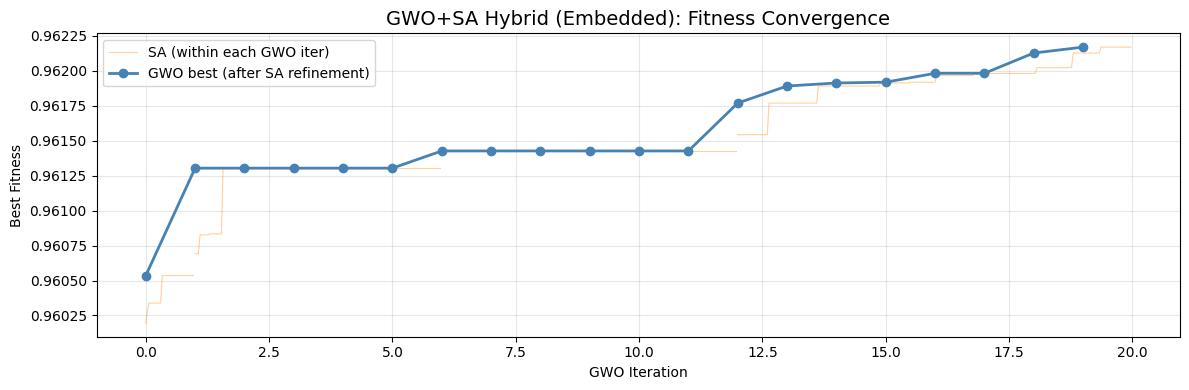


最終モデル学習中...
time: 12.87s

【閾値調整結果 (GWO+SA)】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.2084     0.9542     0.8811     0.8984     
0.55       0.1695     0.9415     0.8916     0.9054     
0.60       0.1360     0.9302     0.9004     0.9114     ★
0.65       0.1038     0.9192     0.9089     0.9174     ★
0.70       0.0756     0.9070     0.9148     0.9214     ★
0.75       0.0491     0.8922     0.9186     0.9235     ★
0.80       0.0285     0.8708     0.9161     0.9195     ★
0.85       0.0152     0.8482     0.9096     0.9118     ★
0.90       0.0069     0.8122     0.8935     0.8936     ★
0.95       0.0014     0.7417     0.8572     0.8512     ★
最適閾値 (F1最大): 0.75


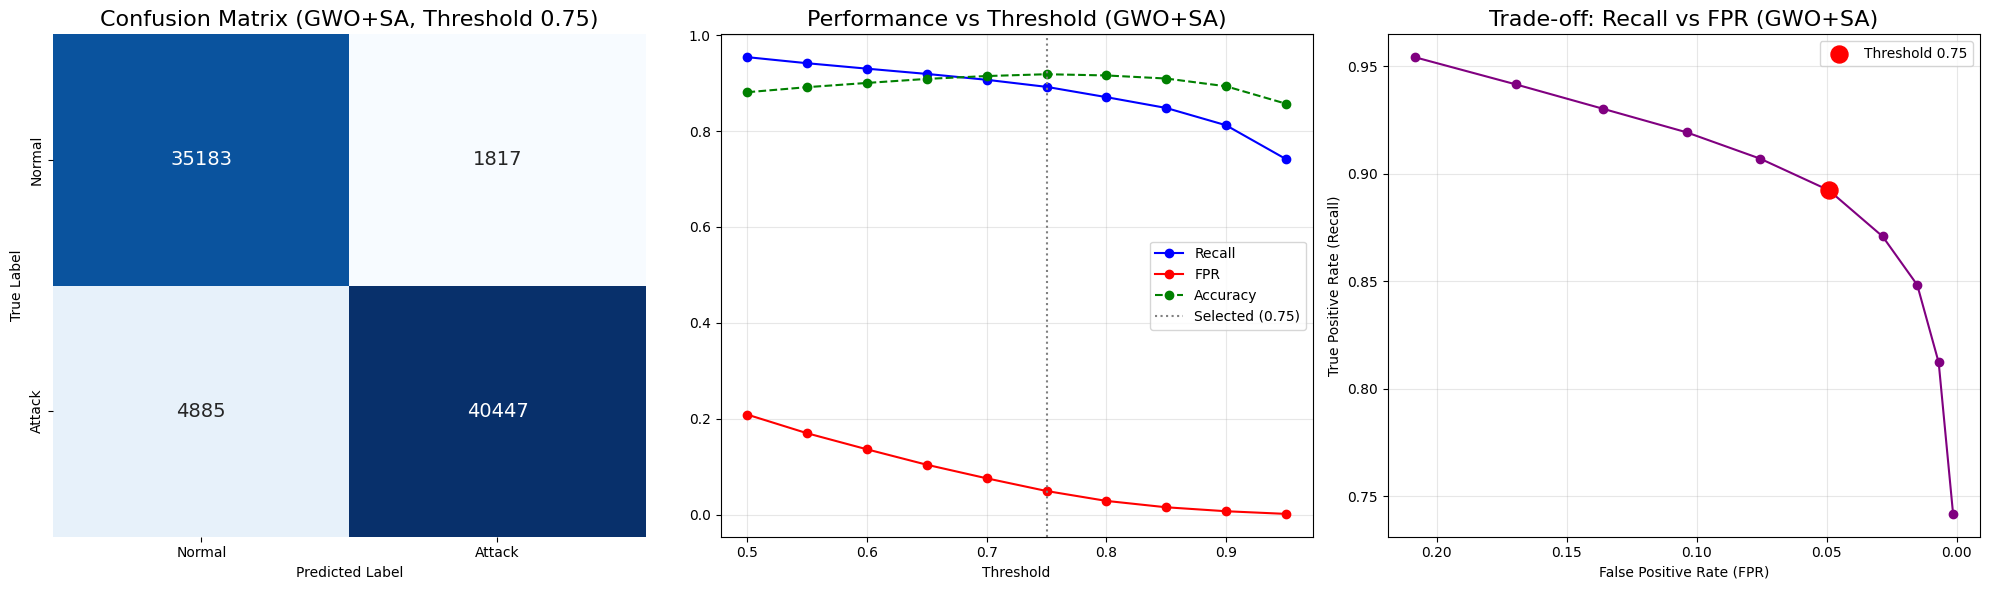

In [ ]:
# ---------------------------------------------------------
# 3. Execution Part
# ---------------------------------------------------------
gwo_sa2 = Hybrid_GWO_SA2(
    n_wolves=15,
    gwo_iter=20,       # GWO: Wide-area Search
    sa_iter=30,       # SA : Local Search
    initial_temp=2.0,  
    cooling_rate=0.997,
    random_state=42
)

start_time_hybrid2 = time.time()
best_mask_gwo_sa = gwo_sa2.optimise(x_train_opt, y_train_opt, x_val_opt, y_val_opt)
print(f"Hybrid GWO-SA (emb) execution finished in: {time.time() - start_time_hybrid2}")

# Mask Transformation
selected_features_gwo_sa2 = best_mask_gwo_sa == 1 
print(f"Final Selected number of Features: {selected_features_gwo_sa2.sum()}")

# GWO+SA Embedded: Convergence Plot
# In the Embedded version, gwo_history (20 data points) represents the “best result (including SA) at each GWO iteration”
# sa_history consists of 30 steps per GWO iteration × 20 iterations = 600 data points
fig_conv, ax_conv = plt.subplots(figsize=(12, 4))

# Split the SA history into 20 blocks (one GWO iteration each) and display them
sa_per_iter = gwo_sa2.sa_iter  # 30
for iter_idx in range(gwo_sa2.gwo_iter):  # 20
    start = iter_idx * sa_per_iter
    end   = start + sa_per_iter
    sa_block = gwo_sa2.sa_history[start:end]
    x_block  = [iter_idx + (j / sa_per_iter) for j in range(sa_per_iter)]
    color = 'darkorange' if iter_idx == 0 else None
    label = 'SA (within each GWO iter)' if iter_idx == 0 else None
    ax_conv.plot(x_block, sa_block, color='darkorange', alpha=0.4,
                 linewidth=0.8, label=label)

# Best per GWO iteration (after SA improvements)
ax_conv.plot(range(gwo_sa2.gwo_iter), gwo_sa2.gwo_history,
             color='steelblue', marker='o', linewidth=2,
             label='GWO best (after SA refinement)', zorder=5)

ax_conv.set_title('GWO+SA Hybrid (Embedded): Fitness Convergence', fontsize=14)
ax_conv.set_xlabel('GWO Iteration')
ax_conv.set_ylabel('Best Fitness')
ax_conv.legend()
ax_conv.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Final model training & threshold adjustment
# ---------------------------------------------------------
x_train_final = x_train_scaled_full[:, selected_features_gwo_sa2]
x_test_final  = x_test_scaled[:, selected_features_gwo_sa2]

final_rf_gwo_sa2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining the final model...")
start_time = time.time()
final_rf_gwo_sa2.fit(x_train_final, y_train_full)
print(f"time: {time.time() - start_time:.2f}s")

y_probs_gwo_sa2 = final_rf_gwo_sa2.predict_proba(x_test_final)[:, 1]

# ---------------------------------------------------------
# 5. Visualization & Trade-off Analysis
# ---------------------------------------------------------
print(f"\n[Threshold Adjustment Results (GWO+SA)]")
print(f"{'Threshold':<10} {'FPR':<10} {'Recall':<10} {'Accuracy':<10} {'F1':<10}")
print("-" * 55)

threshold_list = []
fpr_list       = []
recall_list    = []
accuracy_list  = []

for thr in np.arange(0.5, 0.96, 0.05):
    y_pred_thr = (y_probs_gwo_sa2 >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    TN, FP, FN, TP = cm.ravel()
    fpr = FP / (FP + TN)
    rec = TP / (TP + FN)
    acc = accuracy_score(y_test, y_pred_thr)
    f1  = f1_score(y_test, y_pred_thr, zero_division=0)
    mark = "★" if fpr < 0.15 else ""
    print(f"{thr:<10.2f} {fpr:<10.4f} {rec:<10.4f} {acc:<10.4f} {f1:<10.4f} {mark}")
    threshold_list.append(thr)
    fpr_list.append(fpr)
    recall_list.append(rec)
    accuracy_list.append(acc)

f1_scores_thr = []
for thr_tmp in np.arange(0.3, 0.96, 0.05):
    y_tmp = (y_probs_gwo_sa2 >= thr_tmp).astype(int)
    f1_scores_thr.append(f1_score(y_test, y_tmp, zero_division=0))
SELECTED_THRESHOLD = round(0.3 + np.argmax(f1_scores_thr) * 0.05, 2)
print(f"Optimal Threshold (Max F1): {SELECTED_THRESHOLD}")
y_final_pred = (y_probs_gwo_sa2 >= SELECTED_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_final_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar=False, annot_kws={"size": 14})
axes[0].set_title(f'Confusion Matrix (GWO+SA, Threshold {SELECTED_THRESHOLD})', fontsize=16)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_yticklabels(['Normal', 'Attack'])

axes[1].plot(threshold_list, recall_list,   marker='o', label='Recall',   color='blue')
axes[1].plot(threshold_list, fpr_list,      marker='o', label='FPR',      color='red')
axes[1].plot(threshold_list, accuracy_list, marker='o', label='Accuracy', color='green', linestyle='--')
axes[1].axvline(x=SELECTED_THRESHOLD, color='gray', linestyle=':',
                label=f'Selected ({SELECTED_THRESHOLD})')
axes[1].set_title('Performance vs Threshold (GWO+SA)', fontsize=16)
axes[1].set_xlabel('Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(fpr_list, recall_list, marker='o', linestyle='-', color='purple')
idx = np.argmin(np.abs(np.array(threshold_list) - SELECTED_THRESHOLD))
axes[2].scatter(fpr_list[idx], recall_list[idx], s=150, color='red', zorder=5,
                label=f'Threshold {SELECTED_THRESHOLD}')
axes[2].set_title('Trade-off: Recall vs FPR (GWO+SA)', fontsize=16)
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()


## 8. Hybrid GWO-SA + Optuna 2

--- Hybrid GWO-SA + Optuna: Hyperparameter Tuning Start ---


[I 2026-03-14 22:08:14,288] A new study created in memory with name: no-name-757081a9-a0b5-42f8-9297-b81c30dbc028
[I 2026-03-14 22:08:19,149] Trial 0 finished with value: 0.8937217952778329 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8937217952778329.
[I 2026-03-14 22:08:20,870] Trial 1 finished with value: 0.891759793874902 and parameters: {'n_estimators': 64, 'max_depth': 45, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.8937217952778329.
[I 2026-03-14 22:08:28,044] Trial 2 finished with value: 0.8929046243381324 and parameters: {'n_estimators': 258, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.8937217952778329.
[I 2026-03-14 22:08:32,540] Trial 3 finished with value: 0.8923704769777254 and parameters: {'n_estimators': 158, 'max_depth': 21, 'm


Best Params: {'n_estimators': 88, 'max_depth': 23, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best F1 Score (Validation): 0.8946

【Hybrid GWO-SA + Optuna 最終評価結果】
Threshold  FPR        Recall     Accuracy   F1        
-------------------------------------------------------
0.50       0.2133     0.9556     0.8797     0.8974     
0.55       0.1824     0.9454     0.8880     0.9029     
0.60       0.1533     0.9360     0.8958     0.9082     
0.65       0.1235     0.9253     0.9033     0.9134     ★
0.70       0.0988     0.9147     0.9086     0.9168     ★
0.75       0.0747     0.9019     0.9124     0.9190     ★
0.80       0.0515     0.8869     0.9146     0.9196     ★
0.85       0.0341     0.8672     0.9116     0.9153     ★
0.90       0.0169     0.8427     0.9058     0.9078     ★
0.95       0.0062     0.8007     0.8875     0.8868     ★
最適閾値 (F1最大): 0.8


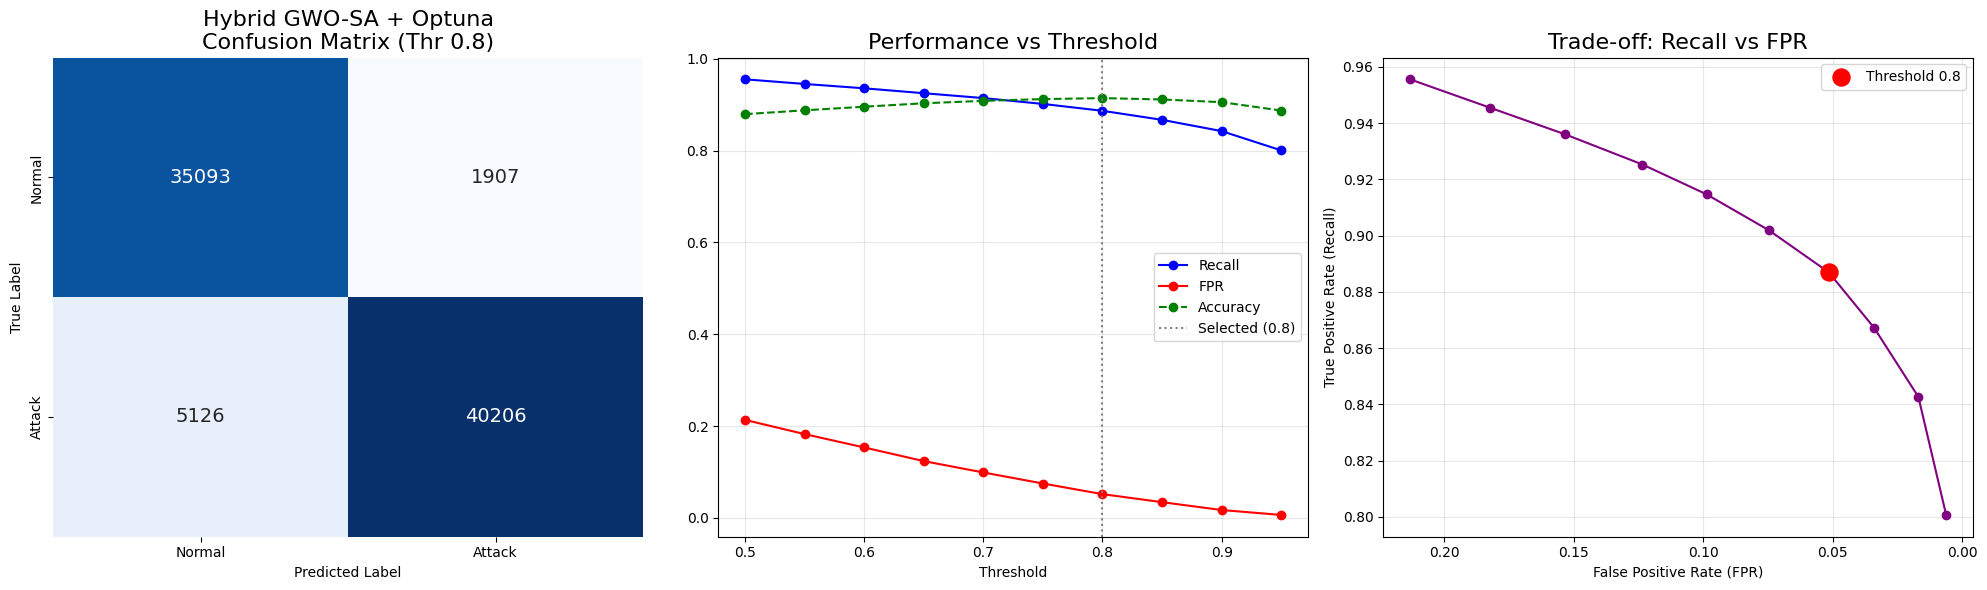

In [30]:
ALGORITHM_NAME = "Hybrid GWO-SA + Optuna"
TARGET_MASK    = selected_features_gwo_sa2

best_model_opt, x_test_opt = run_optuna_optimization(
    TARGET_MASK,
    x_train_opt, y_train_opt,           # Same data as for feature selection
    x_train_scaled_full, y_train_full,  # Data for final training
    x_test_scaled, y_test,
    ALGORITHM_NAME
)

y_probs_opt = best_model_opt.predict_proba(x_test_opt)[:, 1]
evaluate_and_plot(y_probs_opt, y_test, ALGORITHM_NAME)

# 9. Fitness Graph of all metaheuristics

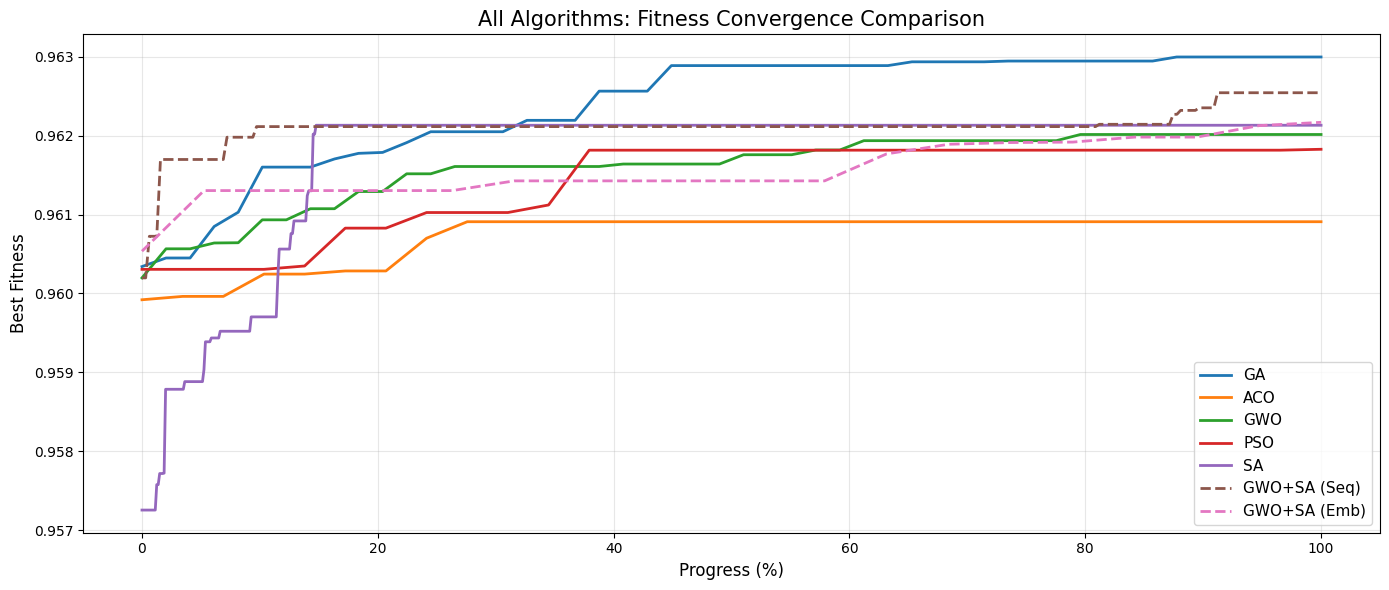

In [31]:
# -------------------------------------------------------------------
# Convergence graph for all algorithms (overlaid on a single sheet)
# -------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

algorithms = [
    ('GA',          ga.fitness_history,              'tab:blue',     '-'),
    ('ACO',         aco.fitness_history,             'tab:orange',   '-'),
    ('GWO',         gwo.fitness_history,             'tab:green',    '-'),
    ('PSO',         pso.fitness_history,             'tab:red',      '-'),
    ('SA',          sa.fitness_history,              'tab:purple',   '-'),
    ('GWO+SA (Seq)',gwo_sa.fitness_history,          'tab:brown',    '--'),  # sequential
    ('GWO+SA (Emb)',gwo_sa2.gwo_history,             'tab:pink',     '--'),  # embedded
]

for name, history, color, ls in algorithms:
    if not history:
        continue
    # Normalize the x-axis to 0–100%
    x_norm = np.linspace(0, 100, len(history))
    ax.plot(x_norm, history, label=name, color=color,
            linestyle=ls, linewidth=2)

ax.set_title('All Algorithms: Fitness Convergence Comparison', fontsize=15)
ax.set_xlabel('Progress (%)', fontsize=12)
ax.set_ylabel('Best Fitness', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Transition of number of selected features

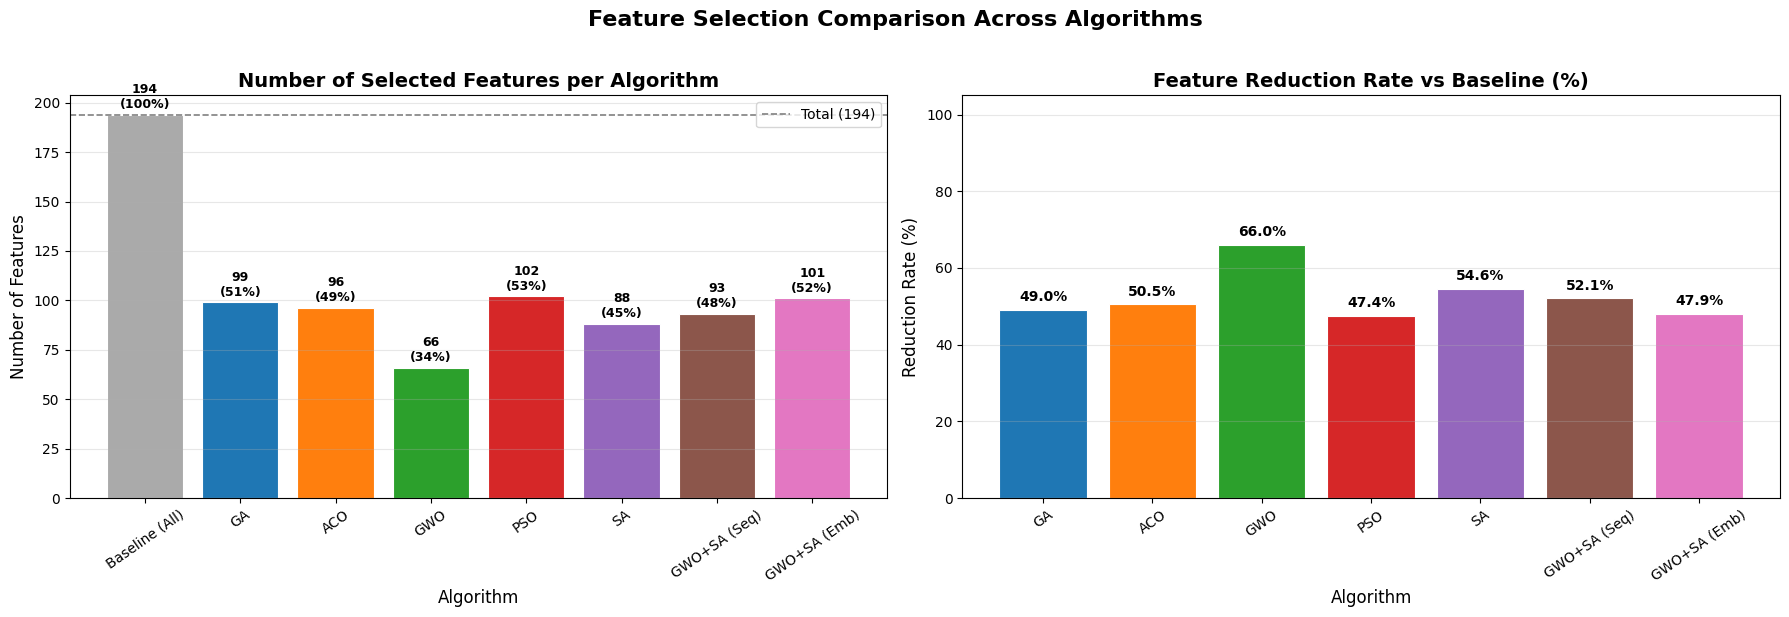

In [32]:
# ------------------------------------------------
# Graph1 : Bar chart of feature reduction rates
# ------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

total_features = x_train_scaled_full.shape[1]

# Define the “Selected number of Features” for each algorithm
# (Since `selected_features` is a boolean array, you can use `.sum()` to get the total number of selected features)
feature_data = [
    ('Baseline (All)',  total_features),
    ('GA',              selected_features_ga.sum()),
    ('ACO',             selected_features_aco.sum()),
    ('GWO',             selected_features_gwo.sum()),
    ('PSO',             selected_features_pso.sum()),
    ('SA',              selected_features_sa.sum()),
    ('GWO+SA (Seq)',    selected_features_gwo_sa.sum()),
    ('GWO+SA (Emb)',    selected_features_gwo_sa2.sum()),
]

names    = [d[0] for d in feature_data]
counts   = [d[1] for d in feature_data]
ratios   = [c / total_features * 100 for c in counts]  # Selection rate (%)
reductions = [100 - r for r in ratios]                  # Reduction rate (%)

# Color coding: Baseline is gray; meta-heuristics are colored
colors = ['#aaaaaa'] + [plt.cm.tab10(i) for i in range(len(names)-1)]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left：Selected number of Features 
bars = axes[0].bar(names, counts, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Number of Selected Features per Algorithm', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_xlabel('Algorithm', fontsize=12)
axes[0].tick_params(axis='x', rotation=35)
axes[0].axhline(y=total_features, color='gray', linestyle='--', linewidth=1.2, label=f'Total ({total_features})')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
# Display the value on the bar
for bar, cnt, rat in zip(bars, counts, ratios):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_features*0.01,
                 f'{cnt}\n({rat:.0f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right：Reduction rate of Features (%) 
bars2 = axes[1].bar(names[1:], reductions[1:], color=colors[1:], edgecolor='white', linewidth=0.8)
axes[1].set_title('Feature Reduction Rate vs Baseline (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Reduction Rate (%)', fontsize=12)
axes[1].set_xlabel('Algorithm', fontsize=12)
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)
for bar, red in zip(bars2, reductions[1:]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{red:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Feature Selection Comparison Across Algorithms', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 11. Comparison of F1 score by changing the threshold

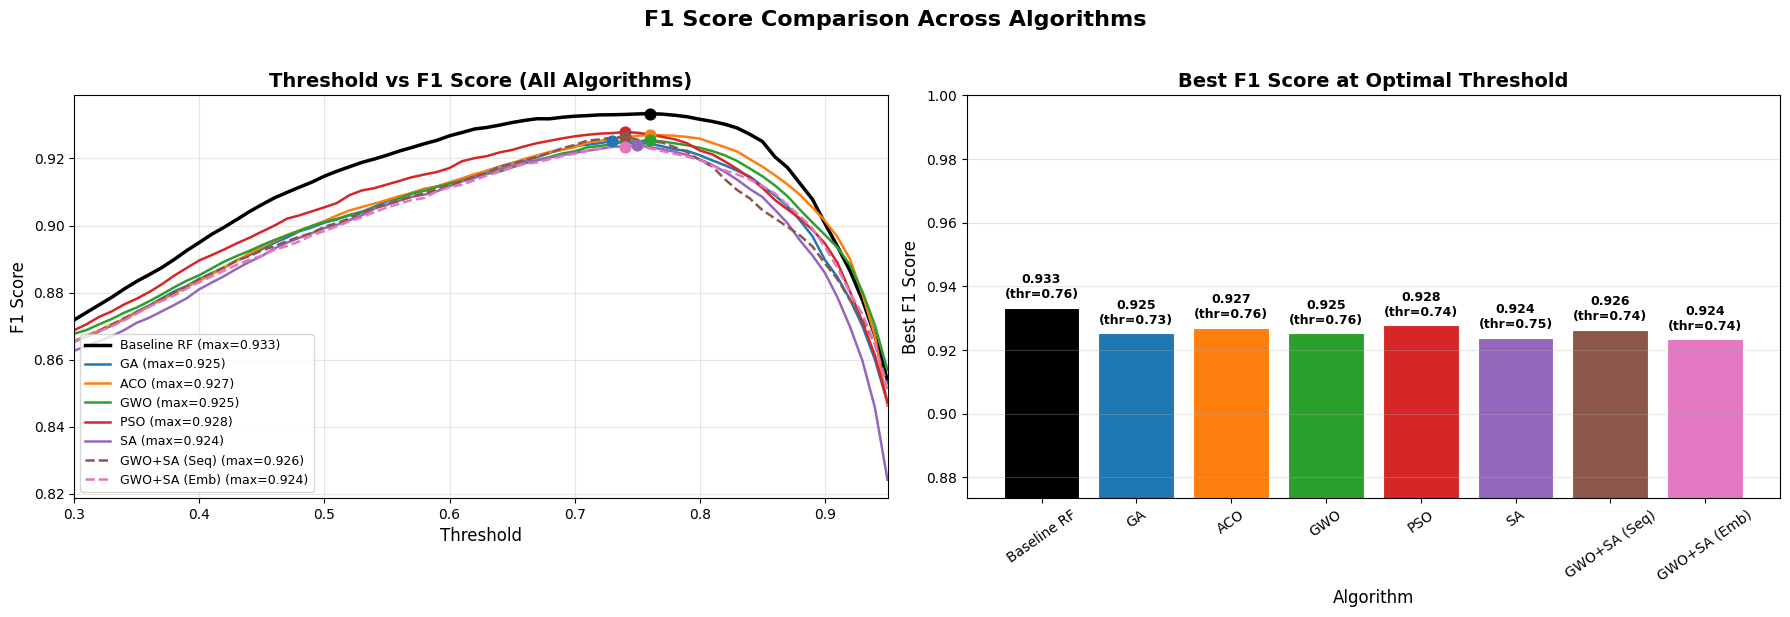

In [33]:
# ---------------------------------------------------------------------
# Graph 2: Threshold vs. F1 Score (Comparison of Multiple Algorithms)
# ---------------------------------------------------------------------

# Define the prediction probabilities, display names, and colors for each algorithm
# List all y_probs for Baseline RF and GA/ACO/GWO/PSO/SA/Hybrid
algo_probs = [
    ('Baseline RF',    y_probs_rf,       'black',       '-',  2.5),
    ('GA',             y_probs_ga,       'tab:blue',    '-',  1.8),
    ('ACO',            y_probs_aco,      'tab:orange',  '-',  1.8),
    ('GWO',            y_probs_gwo,      'tab:green',   '-',  1.8),
    ('PSO',            y_probs_pso,      'tab:red',     '-',  1.8),
    ('SA',             y_probs_sa,       'tab:purple',  '-',  1.8),
    ('GWO+SA (Seq)',   y_probs_gwo_sa,   'tab:brown',   '--', 1.8),
    ('GWO+SA (Emb)',   y_probs_gwo_sa2,  'tab:pink',    '--', 1.8),
]

thresholds = np.arange(0.3, 0.96, 0.01)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

best_points = []   # Save the maximum F1 score for each algorithm

for name, y_probs, color, ls, lw in algo_probs:
    f1_list = []
    for thr in thresholds:
        y_pred = (y_probs >= thr).astype(int)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        f1_list.append(f1)

    f1_arr = np.array(f1_list)
    best_idx = np.argmax(f1_arr)
    best_thr = thresholds[best_idx]
    best_f1  = f1_arr[best_idx]
    best_points.append((name, best_thr, best_f1, color))

    # Left graph: All curves
    axes[0].plot(thresholds, f1_arr, label=f'{name} (max={best_f1:.3f})',
                 color=color, linestyle=ls, linewidth=lw)
    # Mark the maximum point
    axes[0].scatter(best_thr, best_f1, color=color, s=60, zorder=5)

axes[0].set_title('Threshold vs F1 Score (All Algorithms)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].legend(fontsize=9, loc='lower left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0.3, 0.95)

# Right graph: Bar chart comparison of maximum F1 scores
bp_names  = [p[0] for p in best_points]
bp_f1s    = [p[2] for p in best_points]
bp_colors = [p[3] for p in best_points]

bars3 = axes[1].bar(bp_names, bp_f1s, color=bp_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Best F1 Score at Optimal Threshold', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Best F1 Score', fontsize=12)
axes[1].set_xlabel('Algorithm', fontsize=12)
axes[1].tick_params(axis='x', rotation=35)
# Set the lower limit of the y-axis to make the graph easier to read
y_min = max(0, min(bp_f1s) - 0.05)
axes[1].set_ylim(y_min, 1.0)
axes[1].grid(axis='y', alpha=0.3)
for bar, f1, (_, thr, _, _) in zip(bars3, bp_f1s, best_points):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{f1:.3f}\n(thr={thr:.2f})', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

plt.suptitle('F1 Score Comparison Across Algorithms', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()